## Entranamiento del modelo

In [56]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import json

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    auc,
    roc_auc_score,
    classification_report,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
import xgboost
from xgboost import XGBClassifier
import lightgbm
from lightgbm import LGBMClassifier
from pathlib import Path
import sys
import optuna
from optuna.samplers import TPESampler

In [2]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.transformers import MissingIndicatorTransformer

In [24]:
# Cargar el processor (Pipeline transformer)
preprocessor = joblib.load('../artifacts/preprocessors/preprocessor.pkl')

# Cargar el dataset previo a la transformación y/o entrenamiento
X_train_pre = pd.read_parquet('../data/features/X_train_woe.parquet')
y_train_pre = pd.read_parquet('../data/features/y_train_woe.parquet')
X_test_pre = pd.read_parquet('../data/features/X_test_woe.parquet')
y_test_pre = pd.read_parquet('../data/features/y_test_woe.parquet')

# Convertir a column vector
y_train_pre = y_train_pre.squeeze()
y_test_pre = y_test_pre.squeeze()


In [4]:
print(X_train_pre.shape)
print(y_train_pre.shape)

(36422, 15)
(36422,)


### Model Benchmark

#### Logistic Regression

In [ ]:

def objective_logistic(trial, X, y, cv_folds, seed: int, class_weight, preprocessor):
    # Espacio de búsqueda
    param = {
        #'penalty': trial.suggest_categorical('penalty', ['l2']), # pronto se deprecará
        'solver': 'lbfgs',
        'max_iter': trial.suggest_int('max_iter', 100, 300, step = 100),
        'class_weight': class_weight,
        'random_state': seed,
        'C': trial.suggest_float('C', 1e-4, 1e-1)
    }

    # Modelo
    
    model_pipeline = Pipeline(
        steps= [
            ('preprocessor', preprocessor),
            ('model', LogisticRegression(**param))
        ]
    )


    # Evaluación K-folds
    cv = StratifiedKFold(n_splits = cv_folds, shuffle = True, random_state = seed)
    score = cross_val_score(
        model_pipeline,
        X,
        y,
        cv = cv,
        scoring = 'roc_auc'
    ).mean()

    return score

# Optuna optimize (Optuna necesita una función de esta forma: f(trial) → score)
study_logistic = optuna.create_study(study_name='logistic_regression_v1', direction= 'maximize', sampler= TPESampler(seed= 42))
study_logistic.optimize(
    func= lambda trial: objective_logistic(trial, X_train_pre, y_train_pre, 5, 42, 'balanced', preprocessor = preprocessor),
    n_trials = 50,
    show_progress_bar= True
)

#print(study.best_params)
#print(study.best_value)

[I 2026-06-01 12:35:26,224] A new study created in memory with name: logistic_regression_v1
Best trial: 0. Best value: 0.993185:   2%|▏         | 1/50 [00:00<00:13,  3.57it/s]

[I 2026-06-01 12:35:26,508] Trial 0 finished with value: 0.9931849126246697 and parameters: {'max_iter': 200, 'C': 0.09507635921035062}. Best is trial 0 with value: 0.9931849126246697.


Best trial: 0. Best value: 0.993185:   4%|▍         | 2/50 [00:00<00:12,  3.72it/s]

[I 2026-06-01 12:35:26,769] Trial 1 finished with value: 0.9931845203056049 and parameters: {'max_iter': 300, 'C': 0.05990598257128396}. Best is trial 0 with value: 0.9931849126246697.


Best trial: 0. Best value: 0.993185:   6%|▌         | 3/50 [00:00<00:12,  3.87it/s]

[I 2026-06-01 12:35:27,015] Trial 2 finished with value: 0.9931800093000795 and parameters: {'max_iter': 100, 'C': 0.015683852581586645}. Best is trial 0 with value: 0.9931849126246697.


Best trial: 3. Best value: 0.993185:   8%|▊         | 4/50 [00:01<00:11,  3.86it/s]

[I 2026-06-01 12:35:27,276] Trial 3 finished with value: 0.993185071242204 and parameters: {'max_iter': 100, 'C': 0.08663099696291603}. Best is trial 3 with value: 0.993185071242204.


Best trial: 4. Best value: 0.993186:  10%|█         | 5/50 [00:01<00:11,  3.83it/s]

[I 2026-06-01 12:35:27,541] Trial 4 finished with value: 0.993185549361808 and parameters: {'max_iter': 200, 'C': 0.07083645052182494}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  12%|█▏        | 6/50 [00:01<00:11,  3.83it/s]

[I 2026-06-01 12:35:27,802] Trial 5 finished with value: 0.9931839627055226 and parameters: {'max_iter': 100, 'C': 0.09699399423098323}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  14%|█▍        | 7/50 [00:01<00:11,  3.88it/s]

[I 2026-06-01 12:35:28,053] Trial 6 finished with value: 0.9931832588645271 and parameters: {'max_iter': 300, 'C': 0.021312677156759788}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  16%|█▌        | 8/50 [00:02<00:10,  3.88it/s]

[I 2026-06-01 12:35:28,311] Trial 7 finished with value: 0.9931827826455188 and parameters: {'max_iter': 100, 'C': 0.01842211053435804}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  18%|█▊        | 9/50 [00:02<00:10,  3.88it/s]

[I 2026-06-01 12:35:28,568] Trial 8 finished with value: 0.9931844406991456 and parameters: {'max_iter': 100, 'C': 0.05252316752006056}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  20%|██        | 10/50 [00:02<00:10,  3.91it/s]

[I 2026-06-01 12:35:28,820] Trial 9 finished with value: 0.9931848409983491 and parameters: {'max_iter': 200, 'C': 0.02919379110578439}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  22%|██▏       | 11/50 [00:02<00:10,  3.87it/s]

[I 2026-06-01 12:35:29,084] Trial 10 finished with value: 0.9931851527378152 and parameters: {'max_iter': 200, 'C': 0.07174238283393479}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  24%|██▍       | 12/50 [00:03<00:09,  3.86it/s]

[I 2026-06-01 12:35:29,345] Trial 11 finished with value: 0.9931848362011293 and parameters: {'max_iter': 200, 'C': 0.07209325475453916}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  26%|██▌       | 13/50 [00:03<00:09,  3.82it/s]

[I 2026-06-01 12:35:29,613] Trial 12 finished with value: 0.9931849156014977 and parameters: {'max_iter': 200, 'C': 0.07334651460601163}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  28%|██▊       | 14/50 [00:03<00:09,  3.86it/s]

[I 2026-06-01 12:35:29,865] Trial 13 finished with value: 0.993184760281325 and parameters: {'max_iter': 300, 'C': 0.03930604392105298}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  30%|███       | 15/50 [00:03<00:08,  3.94it/s]

[I 2026-06-01 12:35:30,107] Trial 14 finished with value: 0.9925365457679971 and parameters: {'max_iter': 200, 'C': 0.0014163555730877103}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  32%|███▏      | 16/50 [00:04<00:08,  3.89it/s]

[I 2026-06-01 12:35:30,372] Trial 15 finished with value: 0.9931851525546126 and parameters: {'max_iter': 200, 'C': 0.06995397798631267}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  34%|███▍      | 17/50 [00:04<00:08,  3.86it/s]

[I 2026-06-01 12:35:30,635] Trial 16 finished with value: 0.9931853094547535 and parameters: {'max_iter': 300, 'C': 0.08083075311648646}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  36%|███▌      | 18/50 [00:04<00:08,  3.83it/s]

[I 2026-06-01 12:35:30,901] Trial 17 finished with value: 0.9931852298368499 and parameters: {'max_iter': 300, 'C': 0.08583521307660723}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  38%|███▊      | 19/50 [00:04<00:08,  3.70it/s]

[I 2026-06-01 12:35:31,193] Trial 18 finished with value: 0.9931839658082374 and parameters: {'max_iter': 300, 'C': 0.05920919522941297}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  40%|████      | 20/50 [00:05<00:08,  3.72it/s]

[I 2026-06-01 12:35:31,459] Trial 19 finished with value: 0.9931847551520327 and parameters: {'max_iter': 300, 'C': 0.0819589754900734}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  42%|████▏     | 21/50 [00:05<00:07,  3.76it/s]

[I 2026-06-01 12:35:31,717] Trial 20 finished with value: 0.9931842044100805 and parameters: {'max_iter': 300, 'C': 0.04801244810002199}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  44%|████▍     | 22/50 [00:05<00:07,  3.77it/s]

[I 2026-06-01 12:35:31,981] Trial 21 finished with value: 0.9931852296193145 and parameters: {'max_iter': 300, 'C': 0.08541861369599807}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  46%|████▌     | 23/50 [00:06<00:07,  3.77it/s]

[I 2026-06-01 12:35:32,247] Trial 22 finished with value: 0.9931848338654626 and parameters: {'max_iter': 300, 'C': 0.082925899257497}. Best is trial 4 with value: 0.993185549361808.


Best trial: 4. Best value: 0.993186:  48%|████▊     | 24/50 [00:06<00:06,  3.77it/s]

[I 2026-06-01 12:35:32,512] Trial 23 finished with value: 0.9931842795512977 and parameters: {'max_iter': 300, 'C': 0.09960205152156879}. Best is trial 4 with value: 0.993185549361808.


Best trial: 24. Best value: 0.993186:  50%|█████     | 25/50 [00:06<00:06,  3.79it/s]

[I 2026-06-01 12:35:32,773] Trial 24 finished with value: 0.9931856298040757 and parameters: {'max_iter': 200, 'C': 0.06163136094012649}. Best is trial 24 with value: 0.9931856298040757.


Best trial: 24. Best value: 0.993186:  52%|█████▏    | 26/50 [00:06<00:06,  3.79it/s]

[I 2026-06-01 12:35:33,036] Trial 25 finished with value: 0.9931845999349527 and parameters: {'max_iter': 200, 'C': 0.06028253712661808}. Best is trial 24 with value: 0.9931856298040757.


Best trial: 26. Best value: 0.993186:  54%|█████▍    | 27/50 [00:07<00:06,  3.83it/s]

[I 2026-06-01 12:35:33,291] Trial 26 finished with value: 0.9931863443959472 and parameters: {'max_iter': 200, 'C': 0.04403306994961265}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  56%|█████▌    | 28/50 [00:07<00:05,  3.80it/s]

[I 2026-06-01 12:35:33,559] Trial 27 finished with value: 0.9931850772416372 and parameters: {'max_iter': 200, 'C': 0.03875145795596631}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  58%|█████▊    | 29/50 [00:07<00:05,  3.83it/s]

[I 2026-06-01 12:35:33,815] Trial 28 finished with value: 0.9931846814534524 and parameters: {'max_iter': 200, 'C': 0.0466251038299611}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  60%|██████    | 30/50 [00:07<00:05,  3.85it/s]

[I 2026-06-01 12:35:34,072] Trial 29 finished with value: 0.993184443332457 and parameters: {'max_iter': 200, 'C': 0.038920162951123306}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  62%|██████▏   | 31/50 [00:08<00:04,  3.82it/s]

[I 2026-06-01 12:35:34,337] Trial 30 finished with value: 0.9931843602339893 and parameters: {'max_iter': 200, 'C': 0.06481340405539737}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  64%|██████▍   | 32/50 [00:08<00:04,  3.81it/s]

[I 2026-06-01 12:35:34,602] Trial 31 finished with value: 0.9931853094089764 and parameters: {'max_iter': 200, 'C': 0.07875352260545285}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  66%|██████▌   | 33/50 [00:08<00:04,  3.81it/s]

[I 2026-06-01 12:35:34,864] Trial 32 finished with value: 0.9931861030233671 and parameters: {'max_iter': 200, 'C': 0.09212490830209397}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  68%|██████▊   | 34/50 [00:08<00:04,  3.77it/s]

[I 2026-06-01 12:35:35,135] Trial 33 finished with value: 0.9931856274569648 and parameters: {'max_iter': 200, 'C': 0.09303722831688482}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  70%|███████   | 35/50 [00:09<00:03,  3.78it/s]

[I 2026-06-01 12:35:35,398] Trial 34 finished with value: 0.9931856278462584 and parameters: {'max_iter': 200, 'C': 0.0899985981043564}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  72%|███████▏  | 36/50 [00:09<00:03,  3.76it/s]

[I 2026-06-01 12:35:35,668] Trial 35 finished with value: 0.9931857856394288 and parameters: {'max_iter': 100, 'C': 0.09293737246719165}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  74%|███████▍  | 37/50 [00:09<00:03,  3.82it/s]

[I 2026-06-01 12:35:35,920] Trial 36 finished with value: 0.9931859506685783 and parameters: {'max_iter': 100, 'C': 0.03168531413367241}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  76%|███████▌  | 38/50 [00:09<00:03,  3.88it/s]

[I 2026-06-01 12:35:36,168] Trial 37 finished with value: 0.9931853163357719 and parameters: {'max_iter': 100, 'C': 0.02877358673150616}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  78%|███████▊  | 39/50 [00:10<00:02,  3.88it/s]

[I 2026-06-01 12:35:36,425] Trial 38 finished with value: 0.9931846828387737 and parameters: {'max_iter': 100, 'C': 0.030652878154423514}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  80%|████████  | 40/50 [00:10<00:02,  3.87it/s]

[I 2026-06-01 12:35:36,686] Trial 39 finished with value: 0.9931845196529989 and parameters: {'max_iter': 100, 'C': 0.05275441933791347}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  82%|████████▏ | 41/50 [00:10<00:02,  3.93it/s]

[I 2026-06-01 12:35:36,931] Trial 40 finished with value: 0.9930225141818371 and parameters: {'max_iter': 100, 'C': 0.004829653971930043}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  84%|████████▍ | 42/50 [00:10<00:02,  3.91it/s]

[I 2026-06-01 12:35:37,190] Trial 41 finished with value: 0.9931840512767046 and parameters: {'max_iter': 100, 'C': 0.023643182020350612}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  86%|████████▌ | 43/50 [00:11<00:01,  3.92it/s]

[I 2026-06-01 12:35:37,443] Trial 42 finished with value: 0.9931859480467109 and parameters: {'max_iter': 100, 'C': 0.04320620378478603}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  88%|████████▊ | 44/50 [00:11<00:01,  3.90it/s]

[I 2026-06-01 12:35:37,702] Trial 43 finished with value: 0.9931862652016697 and parameters: {'max_iter': 100, 'C': 0.044054925209078236}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  90%|█████████ | 45/50 [00:11<00:01,  3.89it/s]

[I 2026-06-01 12:35:37,962] Trial 44 finished with value: 0.9931861070420945 and parameters: {'max_iter': 100, 'C': 0.044324940281821615}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  92%|█████████▏| 46/50 [00:11<00:01,  3.92it/s]

[I 2026-06-01 12:35:38,212] Trial 45 finished with value: 0.9931853165075302 and parameters: {'max_iter': 100, 'C': 0.03347305159195123}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  94%|█████████▍| 47/50 [00:12<00:00,  3.90it/s]

[I 2026-06-01 12:35:38,472] Trial 46 finished with value: 0.9931837273895969 and parameters: {'max_iter': 100, 'C': 0.05419748724447251}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  96%|█████████▌| 48/50 [00:12<00:00,  3.89it/s]

[I 2026-06-01 12:35:38,729] Trial 47 finished with value: 0.9931861064238214 and parameters: {'max_iter': 100, 'C': 0.04355518844832072}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186:  98%|█████████▊| 49/50 [00:12<00:00,  3.91it/s]

[I 2026-06-01 12:35:38,982] Trial 48 finished with value: 0.9931858688867662 and parameters: {'max_iter': 100, 'C': 0.04253686139308143}. Best is trial 26 with value: 0.9931863443959472.


Best trial: 26. Best value: 0.993186: 100%|██████████| 50/50 [00:13<00:00,  3.84it/s]

[I 2026-06-01 12:35:39,247] Trial 49 finished with value: 0.99318412393348 and parameters: {'max_iter': 100, 'C': 0.05650863860514962}. Best is trial 26 with value: 0.9931863443959472.
{'max_iter': 200, 'C': 0.04403306994961265}
0.9931863443959472


#### Optimizando con los mejores parámetros - Logistic Regression

In [ ]:
best_params = study_logistic.best_params

final_params = {
    **best_params,
    'solver': 'lbfgs',
    'class_weight': 'balanced',
    'random_state': 42
}

best_model_pipeline = Pipeline(
    steps= [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(**final_params))
    ]
)

best_model_pipeline.fit(X_train_pre, y_train_pre)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('missing_indicator', ...), ('column_transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,['no_of_children']
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in 

#### Métricas del Modelo Logistic Regression

In [33]:
# Predicciones y Probabilidades Logistic - Train
y_train_predictions = best_model_pipeline.predict(X_train_pre)
y_train_predict_proba = best_model_pipeline.predict_proba(X_train_pre)

# Predicciones y Probabilidades Logistic - Validation (llamado como test en este caso)
y_test_predictions_logistic = best_model_pipeline.predict(X_test_pre)
y_test_predict_proba_logistic = best_model_pipeline.predict_proba(X_test_pre)

precision, recall, threshold = precision_recall_curve(y_test_pre, y_test_predict_proba_logistic[:,1])
pr_auc = auc(recall, precision)

metricas_test_logistic = pd.DataFrame([{
    'Modelo': 'Logistic Regression',
    'ROC AUC': roc_auc_score(y_true= y_test_pre, y_score = y_test_predict_proba_logistic[:,1]),
    'PR AUC': pr_auc,
    'Prevalencia': y_test_pre.mean()
}])

In [34]:
metricas_test_logistic

,Modelo,ROC AUC,PR AUC,Prevalencia
0,Logistic Regression,0.992081,0.720258,0.052383


#### Random Forest

In [39]:
def objective_random_forest(trial, X, y, cv_folds, seed: int, preprocessor):
    ## Espacio de estudio
    params = {
        'max_depth': trial.suggest_int('max_depth', 5, 15, step = 5),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step = 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 6, 30, step = 2),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20, step = 1),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
        'class_weight': 'balanced',
        'bootstrap': True,
        'max_samples': trial.suggest_float('max_samples', 0.6, 0.85),
        'criterion': 'gini',
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0001, 0.1, log= True)
    }

    ## Modelo
    pipeline = Pipeline(
        steps = [
            ('preprocessor', preprocessor),
            ('model', RandomForestClassifier(**params))
        ]
    )

    ## Cross Validation

    cv = StratifiedKFold(n_splits = cv_folds, random_state = seed, shuffle= True)
    score = cross_val_score(
        estimator= pipeline,
        X = X,
        y = y,
        cv = cv,
        scoring= 'roc_auc'
    ).mean()

    return score

## Objetivo de estudio
study_rf = optuna.create_study(
    study_name= 'random_forest',
    sampler= TPESampler(seed= 42),
    direction= 'maximize'
)

study_rf.optimize(
    func = lambda trial: objective_random_forest(trial, X_train_pre, y_train_pre, 5, 42, preprocessor),
    n_trials= 50,
    show_progress_bar= True
)

[I 2026-06-02 16:41:15,063] A new study created in memory with name: random_forest
Best trial: 0. Best value: 0.994925:   2%|▏         | 1/50 [00:10<08:15, 10.12s/it]

[I 2026-06-02 16:41:25,184] Trial 0 finished with value: 0.9949247867274259 and parameters: {'max_depth': 10, 'n_estimators': 300, 'min_samples_split': 24, 'min_samples_leaf': 14, 'max_features': 'sqrt', 'max_samples': 0.6145209030420499, 'ccp_alpha': 0.0396760507705299}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:   4%|▍         | 2/50 [00:18<07:27,  9.32s/it]

[I 2026-06-02 16:41:33,939] Trial 1 finished with value: 0.9945363313247035 and parameters: {'max_depth': 10, 'n_estimators': 250, 'min_samples_split': 6, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_samples': 0.6454562418017751, 'ccp_alpha': 0.0003549878832196505}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:   6%|▌         | 3/50 [00:24<05:55,  7.57s/it]

[I 2026-06-02 16:41:39,425] Trial 2 finished with value: 0.993525251839044 and parameters: {'max_depth': 5, 'n_estimators': 200, 'min_samples_split': 16, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'max_samples': 0.6730361621338046, 'ccp_alpha': 0.001256277350380704}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:   8%|▊         | 4/50 [00:34<06:27,  8.42s/it]

[I 2026-06-02 16:41:49,143] Trial 3 finished with value: 0.9944193739522127 and parameters: {'max_depth': 10, 'n_estimators': 250, 'min_samples_split': 10, 'min_samples_leaf': 13, 'max_features': 'sqrt', 'max_samples': 0.7518862129753596, 'ccp_alpha': 0.00032476735706274504}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:  10%|█         | 5/50 [00:42<06:21,  8.49s/it]

[I 2026-06-02 16:41:57,754] Trial 4 finished with value: 0.9936053470489303 and parameters: {'max_depth': 5, 'n_estimators': 300, 'min_samples_split': 30, 'min_samples_leaf': 17, 'max_features': 'sqrt', 'max_samples': 0.7710582566280392, 'ccp_alpha': 0.0020914981329035616}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:  12%|█▏        | 6/50 [00:46<05:00,  6.83s/it]

[I 2026-06-02 16:42:01,381] Trial 5 finished with value: 0.9939302203113215 and parameters: {'max_depth': 5, 'n_estimators': 150, 'min_samples_split': 6, 'min_samples_leaf': 19, 'max_features': 'log2', 'max_samples': 0.6779277690223527, 'ccp_alpha': 0.0036324869566766076}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:  14%|█▍        | 7/50 [00:50<04:12,  5.87s/it]

[I 2026-06-02 16:42:05,257] Trial 6 finished with value: 0.9938959663601222 and parameters: {'max_depth': 10, 'n_estimators': 100, 'min_samples_split': 30, 'min_samples_leaf': 17, 'max_features': 'sqrt', 'max_samples': 0.7494749947027712, 'ccp_alpha': 0.058293845429947415}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:  16%|█▌        | 8/50 [00:53<03:28,  4.96s/it]

[I 2026-06-02 16:42:08,260] Trial 7 finished with value: 0.9935735211142205 and parameters: {'max_depth': 5, 'n_estimators': 100, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_samples': 0.8071843772879823, 'ccp_alpha': 0.0011756010900231852}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:  18%|█▊        | 9/50 [00:58<03:27,  5.05s/it]

[I 2026-06-02 16:42:13,524] Trial 8 finished with value: 0.993757280010855 and parameters: {'max_depth': 5, 'n_estimators': 200, 'min_samples_split': 8, 'min_samples_leaf': 17, 'max_features': 'log2', 'max_samples': 0.7930611923241644, 'ccp_alpha': 0.00039459088111000007}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:  20%|██        | 10/50 [01:05<03:44,  5.61s/it]

[I 2026-06-02 16:42:20,399] Trial 9 finished with value: 0.9937298260870012 and parameters: {'max_depth': 5, 'n_estimators': 250, 'min_samples_split': 24, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'max_samples': 0.6896164321360682, 'ccp_alpha': 0.00022264204303769702}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:  22%|██▏       | 11/50 [01:07<02:54,  4.48s/it]

[I 2026-06-02 16:42:22,306] Trial 10 finished with value: 0.9862765242819856 and parameters: {'max_depth': 15, 'n_estimators': 50, 'min_samples_split': 22, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_samples': 0.6096812999902957, 'ccp_alpha': 0.08258341134834689}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:  24%|██▍       | 12/50 [01:17<04:01,  6.35s/it]

[I 2026-06-02 16:42:32,929] Trial 11 finished with value: 0.9948191689981722 and parameters: {'max_depth': 15, 'n_estimators': 300, 'min_samples_split': 14, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_samples': 0.6037207263606942, 'ccp_alpha': 0.01842276777840619}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:  26%|██▌       | 13/50 [01:27<04:34,  7.41s/it]

[I 2026-06-02 16:42:42,776] Trial 12 finished with value: 0.9948303383529311 and parameters: {'max_depth': 15, 'n_estimators': 300, 'min_samples_split': 14, 'min_samples_leaf': 13, 'max_features': 'sqrt', 'max_samples': 0.6009033877049108, 'ccp_alpha': 0.017186844004627465}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:  28%|██▊       | 14/50 [01:37<04:53,  8.15s/it]

[I 2026-06-02 16:42:52,647] Trial 13 finished with value: 0.9947972608942074 and parameters: {'max_depth': 15, 'n_estimators': 300, 'min_samples_split': 22, 'min_samples_leaf': 13, 'max_features': 'sqrt', 'max_samples': 0.6374555501919276, 'ccp_alpha': 0.013675191184068168}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:  30%|███       | 15/50 [01:48<05:14,  8.99s/it]

[I 2026-06-02 16:43:03,574] Trial 14 finished with value: 0.9947301532863889 and parameters: {'max_depth': 15, 'n_estimators': 300, 'min_samples_split': 12, 'min_samples_leaf': 11, 'max_features': 'log2', 'max_samples': 0.842183604693078, 'ccp_alpha': 0.017848224345547843}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 0. Best value: 0.994925:  32%|███▏      | 16/50 [01:56<04:59,  8.80s/it]

[I 2026-06-02 16:43:11,944] Trial 15 finished with value: 0.9947364515954223 and parameters: {'max_depth': 10, 'n_estimators': 250, 'min_samples_split': 18, 'min_samples_leaf': 14, 'max_features': 'sqrt', 'max_samples': 0.71508212455273, 'ccp_alpha': 0.008402822278146907}. Best is trial 0 with value: 0.9949247867274259.


Best trial: 16. Best value: 0.995227:  34%|███▍      | 17/50 [02:02<04:23,  7.97s/it]

[I 2026-06-02 16:43:17,986] Trial 16 finished with value: 0.9952274534650833 and parameters: {'max_depth': 10, 'n_estimators': 200, 'min_samples_split': 26, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_samples': 0.6368247170838579, 'ccp_alpha': 0.04493482522585713}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  36%|███▌      | 18/50 [02:07<03:42,  6.95s/it]

[I 2026-06-02 16:43:22,557] Trial 17 finished with value: 0.9950282999215766 and parameters: {'max_depth': 10, 'n_estimators': 150, 'min_samples_split': 26, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'max_samples': 0.6411316424413209, 'ccp_alpha': 0.04190825765880233}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  38%|███▊      | 19/50 [02:11<03:10,  6.14s/it]

[I 2026-06-02 16:43:26,801] Trial 18 finished with value: 0.994711009254759 and parameters: {'max_depth': 10, 'n_estimators': 150, 'min_samples_split': 26, 'min_samples_leaf': 7, 'max_features': 'log2', 'max_samples': 0.6507937320070546, 'ccp_alpha': 0.03862124002368107}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  40%|████      | 20/50 [02:16<02:52,  5.76s/it]

[I 2026-06-02 16:43:31,686] Trial 19 finished with value: 0.994893793539951 and parameters: {'max_depth': 10, 'n_estimators': 150, 'min_samples_split': 28, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'max_samples': 0.70902495839307, 'ccp_alpha': 0.007625344687909916}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  42%|████▏     | 21/50 [02:19<02:23,  4.96s/it]

[I 2026-06-02 16:43:34,774] Trial 20 finished with value: 0.994722358908658 and parameters: {'max_depth': 10, 'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_samples': 0.6357167506364562, 'ccp_alpha': 0.036043136756947994}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  44%|████▍     | 22/50 [02:25<02:27,  5.27s/it]

[I 2026-06-02 16:43:40,777] Trial 21 finished with value: 0.9948421962270853 and parameters: {'max_depth': 10, 'n_estimators': 200, 'min_samples_split': 26, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_samples': 0.6238460410086912, 'ccp_alpha': 0.041122297157191734}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  46%|████▌     | 23/50 [02:27<01:53,  4.20s/it]

[I 2026-06-02 16:43:42,489] Trial 22 finished with value: 0.9931743652056128 and parameters: {'max_depth': 10, 'n_estimators': 50, 'min_samples_split': 26, 'min_samples_leaf': 11, 'max_features': 'sqrt', 'max_samples': 0.660488264863038, 'ccp_alpha': 0.07316083424947319}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  48%|████▊     | 24/50 [02:33<02:03,  4.73s/it]

[I 2026-06-02 16:43:48,461] Trial 23 finished with value: 0.9947259230789655 and parameters: {'max_depth': 10, 'n_estimators': 200, 'min_samples_split': 22, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'max_samples': 0.6257040536972673, 'ccp_alpha': 0.027765709101171168}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  50%|█████     | 25/50 [02:38<01:58,  4.74s/it]

[I 2026-06-02 16:43:53,210] Trial 24 finished with value: 0.9929549180400752 and parameters: {'max_depth': 10, 'n_estimators': 150, 'min_samples_split': 28, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'max_samples': 0.6902903033918287, 'ccp_alpha': 0.09122535582666257}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  52%|█████▏    | 26/50 [02:41<01:42,  4.28s/it]

[I 2026-06-02 16:43:56,405] Trial 25 finished with value: 0.9945025610754861 and parameters: {'max_depth': 10, 'n_estimators': 100, 'min_samples_split': 24, 'min_samples_leaf': 11, 'max_features': 'sqrt', 'max_samples': 0.6551082236487974, 'ccp_alpha': 0.006869232380444543}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  54%|█████▍    | 27/50 [02:48<01:56,  5.07s/it]

[I 2026-06-02 16:44:03,337] Trial 26 finished with value: 0.9944425824189626 and parameters: {'max_depth': 10, 'n_estimators': 250, 'min_samples_split': 20, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_samples': 0.6199790776775344, 'ccp_alpha': 0.004476405176241908}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  56%|█████▌    | 28/50 [02:54<02:01,  5.54s/it]

[I 2026-06-02 16:44:09,973] Trial 27 finished with value: 0.9948626692994005 and parameters: {'max_depth': 15, 'n_estimators': 200, 'min_samples_split': 28, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'max_samples': 0.667014880097783, 'ccp_alpha': 0.05543738515223994}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  58%|█████▊    | 29/50 [02:59<01:52,  5.34s/it]

[I 2026-06-02 16:44:14,853] Trial 28 finished with value: 0.9948637686838024 and parameters: {'max_depth': 10, 'n_estimators': 150, 'min_samples_split': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_samples': 0.703063190503223, 'ccp_alpha': 0.02519213802500726}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  60%|██████    | 30/50 [03:07<02:00,  6.02s/it]

[I 2026-06-02 16:44:22,445] Trial 29 finished with value: 0.9947361592907932 and parameters: {'max_depth': 10, 'n_estimators': 250, 'min_samples_split': 18, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_samples': 0.6375890240914426, 'ccp_alpha': 0.01119713134431867}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  62%|██████▏   | 31/50 [03:14<01:58,  6.22s/it]

[I 2026-06-02 16:44:29,129] Trial 30 finished with value: 0.9944661160806726 and parameters: {'max_depth': 10, 'n_estimators': 200, 'min_samples_split': 30, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'max_samples': 0.7330532019726768, 'ccp_alpha': 0.00011641609056119219}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  64%|██████▍   | 32/50 [03:18<01:43,  5.73s/it]

[I 2026-06-02 16:44:33,729] Trial 31 finished with value: 0.9947531498784056 and parameters: {'max_depth': 10, 'n_estimators': 150, 'min_samples_split': 28, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'max_samples': 0.6466957880765708, 'ccp_alpha': 0.006316490224812814}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  66%|██████▌   | 33/50 [03:23<01:32,  5.43s/it]

[I 2026-06-02 16:44:38,466] Trial 32 finished with value: 0.9950912592262439 and parameters: {'max_depth': 10, 'n_estimators': 150, 'min_samples_split': 26, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_samples': 0.6846847604359193, 'ccp_alpha': 0.026323755033978824}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 16. Best value: 0.995227:  68%|██████▊   | 34/50 [03:26<01:16,  4.77s/it]

[I 2026-06-02 16:44:41,696] Trial 33 finished with value: 0.9946575461048249 and parameters: {'max_depth': 10, 'n_estimators': 100, 'min_samples_split': 26, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_samples': 0.6803322774350758, 'ccp_alpha': 0.02685229086278776}. Best is trial 16 with value: 0.9952274534650833.


Best trial: 34. Best value: 0.995332:  70%|███████   | 35/50 [03:30<01:05,  4.38s/it]

[I 2026-06-02 16:44:45,158] Trial 34 finished with value: 0.9953316820233733 and parameters: {'max_depth': 5, 'n_estimators': 150, 'min_samples_split': 24, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'max_samples': 0.6660398443883285, 'ccp_alpha': 0.04785415644666737}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  72%|███████▏  | 36/50 [03:33<00:57,  4.12s/it]

[I 2026-06-02 16:44:48,661] Trial 35 finished with value: 0.9952059527252665 and parameters: {'max_depth': 5, 'n_estimators': 150, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'max_samples': 0.6946156922069705, 'ccp_alpha': 0.048029901930582326}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  74%|███████▍  | 37/50 [03:38<00:55,  4.29s/it]

[I 2026-06-02 16:44:53,366] Trial 36 finished with value: 0.9936167590630097 and parameters: {'max_depth': 5, 'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'max_samples': 0.6929875858281569, 'ccp_alpha': 0.059156628269602225}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  76%|███████▌  | 38/50 [03:41<00:49,  4.08s/it]

[I 2026-06-02 16:44:56,964] Trial 37 finished with value: 0.9951557363317388 and parameters: {'max_depth': 5, 'n_estimators': 150, 'min_samples_split': 24, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_samples': 0.7292109924112791, 'ccp_alpha': 0.09896692183968381}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  78%|███████▊  | 39/50 [03:44<00:39,  3.60s/it]

[I 2026-06-02 16:44:59,440] Trial 38 finished with value: 0.9930824785846294 and parameters: {'max_depth': 5, 'n_estimators': 100, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_samples': 0.7345960446370546, 'ccp_alpha': 0.09171358374167228}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  80%|████████  | 40/50 [03:48<00:38,  3.87s/it]

[I 2026-06-02 16:45:03,920] Trial 39 finished with value: 0.9937058925846124 and parameters: {'max_depth': 5, 'n_estimators': 200, 'min_samples_split': 22, 'min_samples_leaf': 9, 'max_features': 'log2', 'max_samples': 0.7665198380468856, 'ccp_alpha': 0.0022341723215410616}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  82%|████████▏ | 41/50 [03:52<00:34,  3.78s/it]

[I 2026-06-02 16:45:07,509] Trial 40 finished with value: 0.9939772243575902 and parameters: {'max_depth': 5, 'n_estimators': 150, 'min_samples_split': 24, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_samples': 0.7221425254834258, 'ccp_alpha': 0.05879503347013044}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  84%|████████▍ | 42/50 [03:55<00:29,  3.67s/it]

[I 2026-06-02 16:45:10,904] Trial 41 finished with value: 0.9949614216191678 and parameters: {'max_depth': 5, 'n_estimators': 150, 'min_samples_split': 24, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_samples': 0.6653963733108543, 'ccp_alpha': 0.027094410776728025}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  86%|████████▌ | 43/50 [03:59<00:25,  3.59s/it]

[I 2026-06-02 16:45:14,331] Trial 42 finished with value: 0.9948287579923877 and parameters: {'max_depth': 5, 'n_estimators': 150, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_samples': 0.6748773232612528, 'ccp_alpha': 0.09903882608783207}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  88%|████████▊ | 44/50 [04:01<00:19,  3.25s/it]

[I 2026-06-02 16:45:16,762] Trial 43 finished with value: 0.9944482806962617 and parameters: {'max_depth': 5, 'n_estimators': 100, 'min_samples_split': 22, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_samples': 0.7028737549138615, 'ccp_alpha': 0.05781799753363071}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  90%|█████████ | 45/50 [04:05<00:16,  3.39s/it]

[I 2026-06-02 16:45:20,497] Trial 44 finished with value: 0.9952485458917438 and parameters: {'max_depth': 5, 'n_estimators': 150, 'min_samples_split': 30, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_samples': 0.7532543142625947, 'ccp_alpha': 0.04424690471440966}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  92%|█████████▏| 46/50 [04:07<00:12,  3.14s/it]

[I 2026-06-02 16:45:23,053] Trial 45 finished with value: 0.9936929170358498 and parameters: {'max_depth': 5, 'n_estimators': 100, 'min_samples_split': 30, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'max_samples': 0.7589422956160632, 'ccp_alpha': 0.0005711664010110515}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  94%|█████████▍| 47/50 [04:12<00:11,  3.70s/it]

[I 2026-06-02 16:45:28,052] Trial 46 finished with value: 0.9952457460671015 and parameters: {'max_depth': 5, 'n_estimators': 200, 'min_samples_split': 30, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_samples': 0.7858077256656613, 'ccp_alpha': 0.04618105138633106}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  96%|█████████▌| 48/50 [04:17<00:07,  3.98s/it]

[I 2026-06-02 16:45:32,683] Trial 47 finished with value: 0.994231198949722 and parameters: {'max_depth': 5, 'n_estimators': 200, 'min_samples_split': 30, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_samples': 0.7984163765636288, 'ccp_alpha': 0.013573997145779592}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332:  98%|█████████▊| 49/50 [04:22<00:04,  4.32s/it]

[I 2026-06-02 16:45:37,788] Trial 48 finished with value: 0.9946848153019774 and parameters: {'max_depth': 5, 'n_estimators': 200, 'min_samples_split': 28, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_samples': 0.7866168600774696, 'ccp_alpha': 0.019911183323715626}. Best is trial 34 with value: 0.9953316820233733.


Best trial: 34. Best value: 0.995332: 100%|██████████| 50/50 [04:30<00:00,  5.40s/it]

[I 2026-06-02 16:45:45,083] Trial 49 finished with value: 0.9949864458707299 and parameters: {'max_depth': 5, 'n_estimators': 250, 'min_samples_split': 30, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_samples': 0.823301961418807, 'ccp_alpha': 0.04346072340693788}. Best is trial 34 with value: 0.9953316820233733.


In [42]:
final_params_rf = {
    **study_rf.best_params,
    'random_state': 42,
    'class_weight': 'balanced',
    'bootstrap': True,
    'criterion': 'gini',
}

pipeline_best_rf = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            **final_params_rf
        ))
    ]
)
pipeline_best_rf.fit(X_train_pre, y_train_pre)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('missing_indicator', ...), ('column_transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,['no_of_children']
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in 

In [43]:
proba_test_rf = pipeline_best_rf.predict_proba(X_test_pre)
precision, recall, threshold = precision_recall_curve(y_true = y_test_pre, y_score = proba_test_rf[:,1])
pr_auc_rf = auc(recall, precision)

metricas_test_rf = pd.DataFrame([{
    'Modelo': 'Random Forest',
    'ROC AUC': roc_auc_score(y_true= y_test_pre, y_score = proba_test_rf[:,1]),
    'PR AUC': pr_auc_rf,
    'Prevalencia': y_test_pre.mean()
}])

### XGBoost

In [48]:
def objective_xgboost(trial, X, y, cv_folds, seed, preprocessor):
    ## Espacio de estudio
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400, step= 50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0.01, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10),
        'scale_pos_weight': trial.suggest_int('scale_pos_weight', 5, 30)
    }

    ## Model
    pipeline = Pipeline(
        steps = [
            ('preprocessor', preprocessor),
            ('model', XGBClassifier(**params))
        ]
    )

    ## Cross Validation
    cv = StratifiedKFold(n_splits = cv_folds, shuffle = True, random_state = seed)
    score = cross_val_score(
        estimator = pipeline,
        X = X,
        y = y,
        cv = cv,
        scoring = 'roc_auc'
    ).mean()

    return score

## Creación del study
study_xgboost = optuna.create_study(
    study_name = 'XGBoost Classifier',
    sampler = TPESampler(seed= 42),
    direction = 'maximize'
)

study_xgboost.optimize(
    func = lambda trial: objective_xgboost(trial, X_train_pre, y_train_pre, 5, 42, preprocessor),
    n_trials = 50,
    show_progress_bar = True
)

[I 2026-06-02 21:44:26,906] A new study created in memory with name: XGBoost Classifier
Best trial: 0. Best value: 0.999004:   2%|▏         | 1/50 [00:02<02:00,  2.47s/it]

[I 2026-06-02 21:44:29,375] Trial 0 finished with value: 0.9990037732683144 and parameters: {'n_estimators': 200, 'learning_rate': 0.09556428757689246, 'max_depth': 8, 'min_child_weight': 12, 'gamma': 1.5686262180199408, 'subsample': 0.6467983561008608, 'colsample_bytree': 0.5232334448672797, 'reg_lambda': 8.663099696291603, 'scale_pos_weight': 20}. Best is trial 0 with value: 0.9990037732683144.


Best trial: 0. Best value: 0.999004:   4%|▍         | 2/50 [00:07<02:57,  3.69s/it]

[I 2026-06-02 21:44:33,924] Trial 1 finished with value: 0.9944961197129386 and parameters: {'n_estimators': 300, 'learning_rate': 0.011852604486622221, 'max_depth': 10, 'min_child_weight': 17, 'gamma': 2.1312677156759787, 'subsample': 0.6545474901621302, 'colsample_bytree': 0.5733618039413735, 'reg_lambda': 3.049380007165782, 'scale_pos_weight': 18}. Best is trial 0 with value: 0.9990037732683144.


Best trial: 0. Best value: 0.999004:   6%|▌         | 3/50 [00:09<02:32,  3.24s/it]

[I 2026-06-02 21:44:36,621] Trial 2 finished with value: 0.9989930013290416 and parameters: {'n_estimators': 250, 'learning_rate': 0.036210622617823776, 'max_depth': 7, 'min_child_weight': 3, 'gamma': 2.9285250388668294, 'subsample': 0.7099085529881075, 'colsample_bytree': 0.6824279936868144, 'reg_lambda': 7.853907854316206, 'scale_pos_weight': 10}. Best is trial 0 with value: 0.9990037732683144.


Best trial: 0. Best value: 0.999004:   8%|▊         | 4/50 [00:11<02:02,  2.66s/it]

[I 2026-06-02 21:44:38,389] Trial 3 finished with value: 0.998986063867172 and parameters: {'n_estimators': 250, 'learning_rate': 0.06331731119758383, 'max_depth': 3, 'min_child_weight': 13, 'gamma': 1.7135359956360423, 'subsample': 0.6195154778955838, 'colsample_bytree': 0.8795542149013333, 'reg_lambda': 9.656664010414849, 'scale_pos_weight': 26}. Best is trial 0 with value: 0.9990037732683144.


Best trial: 0. Best value: 0.999004:  10%|█         | 5/50 [00:14<01:59,  2.66s/it]

[I 2026-06-02 21:44:41,041] Trial 4 finished with value: 0.9948988120159281 and parameters: {'n_estimators': 200, 'learning_rate': 0.018790490260574548, 'max_depth': 8, 'min_child_weight': 9, 'gamma': 1.2291619660993405, 'subsample': 0.748553073033381, 'colsample_bytree': 0.5137554084460874, 'reg_lambda': 9.094110816767033, 'scale_pos_weight': 11}. Best is trial 0 with value: 0.9990037732683144.


Best trial: 0. Best value: 0.999004:  12%|█▏        | 6/50 [00:17<02:09,  2.94s/it]

[I 2026-06-02 21:44:44,539] Trial 5 finished with value: 0.9989554241077091 and parameters: {'n_estimators': 300, 'learning_rate': 0.038053996848046986, 'max_depth': 7, 'min_child_weight': 11, 'gamma': 1.8566960107000152, 'subsample': 0.8908753883293676, 'colsample_bytree': 0.8100531293444458, 'reg_lambda': 9.39559442622625, 'scale_pos_weight': 28}. Best is trial 0 with value: 0.9990037732683144.


Best trial: 0. Best value: 0.999004:  14%|█▍        | 7/50 [00:19<01:54,  2.65s/it]

[I 2026-06-02 21:44:46,593] Trial 6 finished with value: 0.998964815789194 and parameters: {'n_estimators': 300, 'learning_rate': 0.09296868115208053, 'max_depth': 3, 'min_child_weight': 4, 'gamma': 0.4618206162162753, 'subsample': 0.6975990992289793, 'colsample_bytree': 0.6554709158757928, 'reg_lambda': 2.7207768274212203, 'scale_pos_weight': 26}. Best is trial 0 with value: 0.9990037732683144.


Best trial: 7. Best value: 0.999029:  16%|█▌        | 8/50 [00:21<01:37,  2.31s/it]

[I 2026-06-02 21:44:48,181] Trial 7 finished with value: 0.9990289468204473 and parameters: {'n_estimators': 200, 'learning_rate': 0.03528410587186427, 'max_depth': 7, 'min_child_weight': 3, 'gamma': 8.023947837732857, 'subsample': 0.6223651931039312, 'colsample_bytree': 0.8947547746402069, 'reg_lambda': 7.724725245273608, 'scale_pos_weight': 10}. Best is trial 7 with value: 0.9990289468204473.


Best trial: 7. Best value: 0.999029:  18%|█▊        | 9/50 [00:22<01:18,  1.91s/it]

[I 2026-06-02 21:44:49,194] Trial 8 finished with value: 0.9989672809335188 and parameters: {'n_estimators': 100, 'learning_rate': 0.08339152856093508, 'max_depth': 8, 'min_child_weight': 15, 'gamma': 7.714990763392598, 'subsample': 0.6222133955202271, 'colsample_bytree': 0.6433862914177091, 'reg_lambda': 1.167531904656046, 'scale_pos_weight': 27}. Best is trial 7 with value: 0.9990289468204473.


Best trial: 7. Best value: 0.999029:  20%|██        | 10/50 [00:24<01:17,  1.93s/it]

[I 2026-06-02 21:44:51,164] Trial 9 finished with value: 0.9989870067906693 and parameters: {'n_estimators': 300, 'learning_rate': 0.03978082223673843, 'max_depth': 3, 'min_child_weight': 7, 'gamma': 3.258581387047203, 'subsample': 0.8188818535014192, 'colsample_bytree': 0.7550229885420853, 'reg_lambda': 8.873255298337503, 'scale_pos_weight': 17}. Best is trial 7 with value: 0.9990289468204473.


Best trial: 7. Best value: 0.999029:  22%|██▏       | 11/50 [00:25<01:11,  1.83s/it]

[I 2026-06-02 21:44:52,763] Trial 10 finished with value: 0.9990060378963493 and parameters: {'n_estimators': 400, 'learning_rate': 0.06507747305038492, 'max_depth': 5, 'min_child_weight': 1, 'gamma': 9.810897552632145, 'subsample': 0.8070741220707436, 'colsample_bytree': 0.8892151043078499, 'reg_lambda': 6.244594436451928, 'scale_pos_weight': 6}. Best is trial 7 with value: 0.9990289468204473.


Best trial: 7. Best value: 0.999029:  24%|██▍       | 12/50 [00:27<01:06,  1.75s/it]

[I 2026-06-02 21:44:54,332] Trial 11 finished with value: 0.9990086902064016 and parameters: {'n_estimators': 400, 'learning_rate': 0.06192234860606633, 'max_depth': 5, 'min_child_weight': 1, 'gamma': 9.907412846825826, 'subsample': 0.8108097698273996, 'colsample_bytree': 0.886877477258843, 'reg_lambda': 6.165955277234408, 'scale_pos_weight': 5}. Best is trial 7 with value: 0.9990289468204473.


Best trial: 12. Best value: 0.999031:  26%|██▌       | 13/50 [00:29<01:04,  1.74s/it]

[I 2026-06-02 21:44:56,056] Trial 12 finished with value: 0.9990312675251978 and parameters: {'n_estimators': 400, 'learning_rate': 0.05196389732937124, 'max_depth': 5, 'min_child_weight': 5, 'gamma': 7.6237972589019245, 'subsample': 0.815323794530997, 'colsample_bytree': 0.8087696049520285, 'reg_lambda': 5.840341480718283, 'scale_pos_weight': 5}. Best is trial 12 with value: 0.9990312675251978.


Best trial: 12. Best value: 0.999031:  28%|██▊       | 14/50 [00:30<00:54,  1.51s/it]

[I 2026-06-02 21:44:57,028] Trial 13 finished with value: 0.998988923063518 and parameters: {'n_estimators': 100, 'learning_rate': 0.04943490344231187, 'max_depth': 5, 'min_child_weight': 5, 'gamma': 6.948992876922404, 'subsample': 0.8662396808013474, 'colsample_bytree': 0.8144891901971804, 'reg_lambda': 4.975883082172416, 'scale_pos_weight': 11}. Best is trial 12 with value: 0.9990312675251978.


Best trial: 12. Best value: 0.999031:  30%|███       | 15/50 [00:31<00:50,  1.44s/it]

[I 2026-06-02 21:44:58,307] Trial 14 finished with value: 0.9990019462063945 and parameters: {'n_estimators': 150, 'learning_rate': 0.027247055587621624, 'max_depth': 6, 'min_child_weight': 20, 'gamma': 6.3145325919542605, 'subsample': 0.7593372091054381, 'colsample_bytree': 0.8145100992960261, 'reg_lambda': 6.894666671618774, 'scale_pos_weight': 8}. Best is trial 12 with value: 0.9990312675251978.


Best trial: 12. Best value: 0.999031:  32%|███▏      | 16/50 [00:33<00:53,  1.57s/it]

[I 2026-06-02 21:45:00,182] Trial 15 finished with value: 0.9990084519872809 and parameters: {'n_estimators': 350, 'learning_rate': 0.047803922532058465, 'max_depth': 10, 'min_child_weight': 8, 'gamma': 8.281147358989108, 'subsample': 0.7655032545961666, 'colsample_bytree': 0.7549318390764551, 'reg_lambda': 4.863200226863267, 'scale_pos_weight': 14}. Best is trial 12 with value: 0.9990312675251978.


Best trial: 12. Best value: 0.999031:  34%|███▍      | 17/50 [00:35<00:55,  1.69s/it]

[I 2026-06-02 21:45:02,164] Trial 16 finished with value: 0.9989768708724671 and parameters: {'n_estimators': 200, 'learning_rate': 0.028806507207668176, 'max_depth': 6, 'min_child_weight': 6, 'gamma': 4.82174713792545, 'subsample': 0.8503592749019637, 'colsample_bytree': 0.7628581217310246, 'reg_lambda': 3.893804255915998, 'scale_pos_weight': 14}. Best is trial 12 with value: 0.9990312675251978.


Best trial: 12. Best value: 0.999031:  36%|███▌      | 18/50 [00:36<00:48,  1.52s/it]

[I 2026-06-02 21:45:03,265] Trial 17 finished with value: 0.9989698962927445 and parameters: {'n_estimators': 150, 'learning_rate': 0.0806196668913283, 'max_depth': 4, 'min_child_weight': 3, 'gamma': 5.274024917295854, 'subsample': 0.7025916092806056, 'colsample_bytree': 0.8454766426631275, 'reg_lambda': 7.453903275687592, 'scale_pos_weight': 8}. Best is trial 12 with value: 0.9990312675251978.


Best trial: 12. Best value: 0.999031:  38%|███▊      | 19/50 [00:37<00:46,  1.50s/it]

[I 2026-06-02 21:45:04,719] Trial 18 finished with value: 0.9989950330391005 and parameters: {'n_estimators': 350, 'learning_rate': 0.07103784718478982, 'max_depth': 4, 'min_child_weight': 9, 'gamma': 8.716169905836528, 'subsample': 0.7814110221812636, 'colsample_bytree': 0.7255898796085732, 'reg_lambda': 5.586978663434355, 'scale_pos_weight': 5}. Best is trial 12 with value: 0.9990312675251978.


Best trial: 12. Best value: 0.999031:  40%|████      | 20/50 [00:39<00:43,  1.47s/it]

[I 2026-06-02 21:45:06,112] Trial 19 finished with value: 0.9989863281732625 and parameters: {'n_estimators': 150, 'learning_rate': 0.05017442260955618, 'max_depth': 9, 'min_child_weight': 6, 'gamma': 5.9741537631111425, 'subsample': 0.7338966025350109, 'colsample_bytree': 0.8478923021714819, 'reg_lambda': 7.9227539848062944, 'scale_pos_weight': 14}. Best is trial 12 with value: 0.9990312675251978.


Best trial: 12. Best value: 0.999031:  42%|████▏     | 21/50 [00:42<00:54,  1.88s/it]

[I 2026-06-02 21:45:08,947] Trial 20 finished with value: 0.9989582316046743 and parameters: {'n_estimators': 350, 'learning_rate': 0.02623754645831629, 'max_depth': 6, 'min_child_weight': 2, 'gamma': 7.132490622136717, 'subsample': 0.6720235478621212, 'colsample_bytree': 0.7937564266357281, 'reg_lambda': 0.1260934066592574, 'scale_pos_weight': 23}. Best is trial 12 with value: 0.9990312675251978.


Best trial: 12. Best value: 0.999031:  44%|████▍     | 22/50 [00:43<00:50,  1.79s/it]

[I 2026-06-02 21:45:10,548] Trial 21 finished with value: 0.9990252120141992 and parameters: {'n_estimators': 400, 'learning_rate': 0.05673790582537745, 'max_depth': 5, 'min_child_weight': 1, 'gamma': 9.940981950873, 'subsample': 0.8156218599876746, 'colsample_bytree': 0.8970910735221578, 'reg_lambda': 6.344721319635075, 'scale_pos_weight': 5}. Best is trial 12 with value: 0.9990312675251978.


Best trial: 12. Best value: 0.999031:  46%|████▌     | 23/50 [00:45<00:47,  1.76s/it]

[I 2026-06-02 21:45:12,223] Trial 22 finished with value: 0.9990263499466094 and parameters: {'n_estimators': 400, 'learning_rate': 0.057114286136797476, 'max_depth': 4, 'min_child_weight': 4, 'gamma': 8.71202128749468, 'subsample': 0.8383990028586045, 'colsample_bytree': 0.8505881852213306, 'reg_lambda': 6.878965377815292, 'scale_pos_weight': 8}. Best is trial 12 with value: 0.9990312675251978.


Best trial: 23. Best value: 0.999035:  48%|████▊     | 24/50 [00:47<00:45,  1.75s/it]

[I 2026-06-02 21:45:13,962] Trial 23 finished with value: 0.9990352237583162 and parameters: {'n_estimators': 350, 'learning_rate': 0.04329780604931113, 'max_depth': 4, 'min_child_weight': 4, 'gamma': 8.801462084879653, 'subsample': 0.8550428065411835, 'colsample_bytree': 0.8507775215003761, 'reg_lambda': 7.089034511225183, 'scale_pos_weight': 9}. Best is trial 23 with value: 0.9990352237583162.


Best trial: 23. Best value: 0.999035:  50%|█████     | 25/50 [00:48<00:44,  1.79s/it]

[I 2026-06-02 21:45:15,850] Trial 24 finished with value: 0.9990062821540147 and parameters: {'n_estimators': 350, 'learning_rate': 0.04301447867794912, 'max_depth': 7, 'min_child_weight': 5, 'gamma': 7.827257435674462, 'subsample': 0.8853463751257779, 'colsample_bytree': 0.8533488556444156, 'reg_lambda': 3.905357126821552, 'scale_pos_weight': 12}. Best is trial 23 with value: 0.9990352237583162.


Best trial: 23. Best value: 0.999035:  52%|█████▏    | 26/50 [00:50<00:41,  1.74s/it]

[I 2026-06-02 21:45:17,480] Trial 25 finished with value: 0.9990226443815923 and parameters: {'n_estimators': 250, 'learning_rate': 0.031960517831591206, 'max_depth': 4, 'min_child_weight': 8, 'gamma': 9.019512388956485, 'subsample': 0.848756555711595, 'colsample_bytree': 0.7873940760990887, 'reg_lambda': 8.319014616956213, 'scale_pos_weight': 8}. Best is trial 23 with value: 0.9990352237583162.


Best trial: 23. Best value: 0.999035:  54%|█████▍    | 27/50 [00:52<00:43,  1.91s/it]

[I 2026-06-02 21:45:19,760] Trial 26 finished with value: 0.9989981638415915 and parameters: {'n_estimators': 350, 'learning_rate': 0.04439282051584546, 'max_depth': 6, 'min_child_weight': 3, 'gamma': 4.725134319004208, 'subsample': 0.7936356519194001, 'colsample_bytree': 0.7168514801545984, 'reg_lambda': 7.154504675576178, 'scale_pos_weight': 9}. Best is trial 23 with value: 0.9990352237583162.


Best trial: 23. Best value: 0.999035:  56%|█████▌    | 28/50 [00:55<00:48,  2.19s/it]

[I 2026-06-02 21:45:22,600] Trial 27 finished with value: 0.9990149567553978 and parameters: {'n_estimators': 400, 'learning_rate': 0.018773967172511077, 'max_depth': 5, 'min_child_weight': 6, 'gamma': 7.257479986195783, 'subsample': 0.8672160107706864, 'colsample_bytree': 0.8633751271451298, 'reg_lambda': 5.424974408254044, 'scale_pos_weight': 13}. Best is trial 23 with value: 0.9990352237583162.


Best trial: 23. Best value: 0.999035:  58%|█████▊    | 29/50 [00:57<00:41,  2.00s/it]

[I 2026-06-02 21:45:24,152] Trial 28 finished with value: 0.9989908657224905 and parameters: {'n_estimators': 200, 'learning_rate': 0.03336967457737562, 'max_depth': 4, 'min_child_weight': 4, 'gamma': 6.319518968157219, 'subsample': 0.826910512661356, 'colsample_bytree': 0.8433730112063279, 'reg_lambda': 4.00847538443046, 'scale_pos_weight': 7}. Best is trial 23 with value: 0.9990352237583162.


Best trial: 23. Best value: 0.999035:  60%|██████    | 30/50 [00:58<00:38,  1.90s/it]

[I 2026-06-02 21:45:25,835] Trial 29 finished with value: 0.99899554930739 and parameters: {'n_estimators': 250, 'learning_rate': 0.05425132102220634, 'max_depth': 9, 'min_child_weight': 11, 'gamma': 9.189347210472965, 'subsample': 0.7796354572660775, 'colsample_bytree': 0.5858291414849965, 'reg_lambda': 8.399986177254316, 'scale_pos_weight': 20}. Best is trial 23 with value: 0.9990352237583162.


Best trial: 23. Best value: 0.999035:  62%|██████▏   | 31/50 [01:00<00:33,  1.78s/it]

[I 2026-06-02 21:45:27,330] Trial 30 finished with value: 0.9989875111289468 and parameters: {'n_estimators': 300, 'learning_rate': 0.07374085606783297, 'max_depth': 7, 'min_child_weight': 13, 'gamma': 8.105698361775158, 'subsample': 0.722822139717165, 'colsample_bytree': 0.8183508512148765, 'reg_lambda': 5.921210501820973, 'scale_pos_weight': 18}. Best is trial 23 with value: 0.9990352237583162.


Best trial: 23. Best value: 0.999035:  64%|██████▍   | 32/50 [01:02<00:31,  1.75s/it]

[I 2026-06-02 21:45:29,027] Trial 31 finished with value: 0.9990226756788132 and parameters: {'n_estimators': 400, 'learning_rate': 0.055980171601217356, 'max_depth': 4, 'min_child_weight': 4, 'gamma': 8.646144147405257, 'subsample': 0.8352789263890413, 'colsample_bytree': 0.8358007346380013, 'reg_lambda': 6.714160494928629, 'scale_pos_weight': 10}. Best is trial 23 with value: 0.9990352237583162.


Best trial: 23. Best value: 0.999035:  66%|██████▌   | 33/50 [01:03<00:29,  1.74s/it]

[I 2026-06-02 21:45:30,740] Trial 32 finished with value: 0.9990286640235299 and parameters: {'n_estimators': 400, 'learning_rate': 0.04392383577604741, 'max_depth': 3, 'min_child_weight': 5, 'gamma': 9.181452683001627, 'subsample': 0.8992634770633438, 'colsample_bytree': 0.8694534304932171, 'reg_lambda': 7.533604436817069, 'scale_pos_weight': 7}. Best is trial 23 with value: 0.9990352237583162.


Best trial: 33. Best value: 0.999037:  68%|██████▊   | 34/50 [01:05<00:27,  1.70s/it]

[I 2026-06-02 21:45:32,337] Trial 33 finished with value: 0.9990369005034214 and parameters: {'n_estimators': 350, 'learning_rate': 0.04366386319616521, 'max_depth': 3, 'min_child_weight': 2, 'gamma': 9.39778629157482, 'subsample': 0.8940532098815199, 'colsample_bytree': 0.8735465985081501, 'reg_lambda': 7.668000155071412, 'scale_pos_weight': 7}. Best is trial 33 with value: 0.9990369005034214.


Best trial: 33. Best value: 0.999037:  70%|███████   | 35/50 [01:07<00:25,  1.72s/it]

[I 2026-06-02 21:45:34,094] Trial 34 finished with value: 0.9990170404632842 and parameters: {'n_estimators': 350, 'learning_rate': 0.038660881423693956, 'max_depth': 3, 'min_child_weight': 3, 'gamma': 7.619026916227216, 'subsample': 0.8663970987909293, 'colsample_bytree': 0.894765744750737, 'reg_lambda': 7.967983776672947, 'scale_pos_weight': 16}. Best is trial 33 with value: 0.9990369005034214.


Best trial: 33. Best value: 0.999037:  72%|███████▏  | 36/50 [01:08<00:22,  1.62s/it]

[I 2026-06-02 21:45:35,496] Trial 35 finished with value: 0.9989757897503371 and parameters: {'n_estimators': 200, 'learning_rate': 0.017882577918226443, 'max_depth': 3, 'min_child_weight': 2, 'gamma': 9.323913120046313, 'subsample': 0.6477866901458057, 'colsample_bytree': 0.7860714579193617, 'reg_lambda': 8.695411910117016, 'scale_pos_weight': 10}. Best is trial 33 with value: 0.9990369005034214.


Best trial: 33. Best value: 0.999037:  74%|███████▍  | 37/50 [01:10<00:22,  1.74s/it]

[I 2026-06-02 21:45:37,524] Trial 36 finished with value: 0.9989913916595603 and parameters: {'n_estimators': 250, 'learning_rate': 0.02271837904193498, 'max_depth': 5, 'min_child_weight': 2, 'gamma': 6.871086956489475, 'subsample': 0.8808437053963832, 'colsample_bytree': 0.8720726726420888, 'reg_lambda': 9.724308949369359, 'scale_pos_weight': 30}. Best is trial 33 with value: 0.9990369005034214.


Best trial: 33. Best value: 0.999037:  76%|███████▌  | 38/50 [01:13<00:24,  2.04s/it]

[I 2026-06-02 21:45:40,263] Trial 37 finished with value: 0.9971059939550168 and parameters: {'n_estimators': 350, 'learning_rate': 0.012088438047196434, 'max_depth': 7, 'min_child_weight': 7, 'gamma': 8.27057002702555, 'subsample': 0.6839449098456987, 'colsample_bytree': 0.5454078948307839, 'reg_lambda': 7.364549908742494, 'scale_pos_weight': 6}. Best is trial 33 with value: 0.9990369005034214.


Best trial: 33. Best value: 0.999037:  78%|███████▊  | 39/50 [01:15<00:23,  2.12s/it]

[I 2026-06-02 21:45:42,549] Trial 38 finished with value: 0.9989478634062936 and parameters: {'n_estimators': 300, 'learning_rate': 0.03340608735907308, 'max_depth': 4, 'min_child_weight': 2, 'gamma': 4.2338116473738125, 'subsample': 0.6089890786563684, 'colsample_bytree': 0.8256610178081264, 'reg_lambda': 5.469168039312651, 'scale_pos_weight': 10}. Best is trial 33 with value: 0.9990369005034214.


Best trial: 39. Best value: 0.999048:  80%|████████  | 40/50 [01:17<00:19,  1.95s/it]

[I 2026-06-02 21:45:44,116] Trial 39 finished with value: 0.9990483487077867 and parameters: {'n_estimators': 300, 'learning_rate': 0.050902777959311155, 'max_depth': 8, 'min_child_weight': 9, 'gamma': 9.581450604230119, 'subsample': 0.8523429533724179, 'colsample_bytree': 0.7741916677495846, 'reg_lambda': 9.2090010999269, 'scale_pos_weight': 12}. Best is trial 39 with value: 0.9990483487077867.


Best trial: 39. Best value: 0.999048:  82%|████████▏ | 41/50 [01:18<00:16,  1.86s/it]

[I 2026-06-02 21:45:45,754] Trial 40 finished with value: 0.9989958697367747 and parameters: {'n_estimators': 300, 'learning_rate': 0.05235367761399407, 'max_depth': 9, 'min_child_weight': 10, 'gamma': 9.515657274023608, 'subsample': 0.8563537859681556, 'colsample_bytree': 0.6828801471952795, 'reg_lambda': 9.87740812551543, 'scale_pos_weight': 12}. Best is trial 39 with value: 0.9990483487077867.


Best trial: 39. Best value: 0.999048:  84%|████████▍ | 42/50 [01:20<00:14,  1.82s/it]

[I 2026-06-02 21:45:47,472] Trial 41 finished with value: 0.9990231875163819 and parameters: {'n_estimators': 350, 'learning_rate': 0.046455790782995346, 'max_depth': 8, 'min_child_weight': 13, 'gamma': 8.430823245469055, 'subsample': 0.8761480593102839, 'colsample_bytree': 0.7981338152976238, 'reg_lambda': 9.10751862631302, 'scale_pos_weight': 9}. Best is trial 39 with value: 0.9990483487077867.


Best trial: 39. Best value: 0.999048:  86%|████████▌ | 43/50 [01:22<00:12,  1.79s/it]

[I 2026-06-02 21:45:49,187] Trial 42 finished with value: 0.9990210457325401 and parameters: {'n_estimators': 300, 'learning_rate': 0.03936960340989526, 'max_depth': 8, 'min_child_weight': 7, 'gamma': 7.787972118276117, 'subsample': 0.8937205932176343, 'colsample_bytree': 0.7742108024059119, 'reg_lambda': 8.27247932074252, 'scale_pos_weight': 7}. Best is trial 39 with value: 0.9990483487077867.


Best trial: 39. Best value: 0.999048:  88%|████████▊ | 44/50 [01:23<00:09,  1.63s/it]

[I 2026-06-02 21:45:50,467] Trial 43 finished with value: 0.9990373715874151 and parameters: {'n_estimators': 250, 'learning_rate': 0.06395896754099481, 'max_depth': 7, 'min_child_weight': 5, 'gamma': 9.68204185180361, 'subsample': 0.8425835722177334, 'colsample_bytree': 0.8684264963903412, 'reg_lambda': 9.163845259650474, 'scale_pos_weight': 12}. Best is trial 39 with value: 0.9990483487077867.


Best trial: 39. Best value: 0.999048:  90%|█████████ | 45/50 [01:24<00:07,  1.57s/it]

[I 2026-06-02 21:45:51,883] Trial 44 finished with value: 0.9990292232208409 and parameters: {'n_estimators': 300, 'learning_rate': 0.0625891226406758, 'max_depth': 8, 'min_child_weight': 16, 'gamma': 9.520095504936691, 'subsample': 0.838045054263729, 'colsample_bytree': 0.8705863478761333, 'reg_lambda': 9.392276931827153, 'scale_pos_weight': 16}. Best is trial 39 with value: 0.9990483487077867.


Best trial: 39. Best value: 0.999048:  92%|█████████▏| 46/50 [01:26<00:05,  1.48s/it]

[I 2026-06-02 21:45:53,150] Trial 45 finished with value: 0.9990213718465466 and parameters: {'n_estimators': 250, 'learning_rate': 0.06013858833127727, 'max_depth': 3, 'min_child_weight': 9, 'gamma': 9.647719617339074, 'subsample': 0.796111088078277, 'colsample_bytree': 0.7417450450171493, 'reg_lambda': 9.08644355988128, 'scale_pos_weight': 12}. Best is trial 39 with value: 0.9990483487077867.


Best trial: 39. Best value: 0.999048:  94%|█████████▍| 47/50 [01:27<00:04,  1.48s/it]

[I 2026-06-02 21:45:54,632] Trial 46 finished with value: 0.9990249963215634 and parameters: {'n_estimators': 350, 'learning_rate': 0.0751141869473359, 'max_depth': 7, 'min_child_weight': 5, 'gamma': 8.906838946473524, 'subsample': 0.8542624646339305, 'colsample_bytree': 0.8318142584872127, 'reg_lambda': 8.696448106524995, 'scale_pos_weight': 9}. Best is trial 39 with value: 0.9990483487077867.


Best trial: 39. Best value: 0.999048:  96%|█████████▌| 48/50 [01:29<00:02,  1.44s/it]

[I 2026-06-02 21:45:55,974] Trial 47 finished with value: 0.9990294473784876 and parameters: {'n_estimators': 250, 'learning_rate': 0.049322071093745964, 'max_depth': 6, 'min_child_weight': 19, 'gamma': 9.947718812430361, 'subsample': 0.8721607025289826, 'colsample_bytree': 0.8017111029585349, 'reg_lambda': 6.5671827641535625, 'scale_pos_weight': 6}. Best is trial 39 with value: 0.9990483487077867.


Best trial: 39. Best value: 0.999048:  98%|█████████▊| 49/50 [01:30<00:01,  1.52s/it]

[I 2026-06-02 21:45:57,672] Trial 48 finished with value: 0.9990181482667312 and parameters: {'n_estimators': 400, 'learning_rate': 0.05962717428859147, 'max_depth': 8, 'min_child_weight': 8, 'gamma': 9.095326160918113, 'subsample': 0.8260900782286604, 'colsample_bytree': 0.8776302684774782, 'reg_lambda': 4.618397820022366, 'scale_pos_weight': 11}. Best is trial 39 with value: 0.9990483487077867.


Best trial: 39. Best value: 0.999048: 100%|██████████| 50/50 [01:32<00:00,  1.85s/it]

[I 2026-06-02 21:45:59,186] Trial 49 finished with value: 0.9990065017044977 and parameters: {'n_estimators': 350, 'learning_rate': 0.06678931866101225, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 7.470335729589662, 'subsample': 0.8036147715498838, 'colsample_bytree': 0.8298992147545384, 'reg_lambda': 7.942969016213361, 'scale_pos_weight': 15}. Best is trial 39 with value: 0.9990483487077867.


In [52]:
best_model_xgboost = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            **study_xgboost.best_params
        ))
    ]
)
best_model_xgboost.fit(X_train_pre, y_train_pre)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('missing_indicator', ...), ('column_transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,['no_of_children']
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in 

In [53]:
proba_test_xgboost = best_model_xgboost.predict_proba(X_test_pre)
precision, recall, threshold = precision_recall_curve(y_true = y_test_pre, y_score = proba_test_xgboost[:,1])
pr_curve_xgboost = auc(recall, precision)

metricas_test_xgboost = pd.DataFrame([{
    'Modelo': 'XGBoost Classifier',
    'ROC AUC': roc_auc_score(y_true= y_test_pre, y_score = proba_test_xgboost[:,1]),
    'PR AUC': pr_curve_xgboost,
    'Prevalencia': y_test_pre.mean()
}])

### LightGBM

In [60]:
def objective_lightgbm(trial, X, y, cv_folds, seed: int, preprocessor):
    ## Espacio de estudio
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 1),
        'num_leaves': trial.suggest_int('num_leaves', 5, 60),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 30),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.9),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 30),
        'scale_pos_weight': trial.suggest_int('scale_pos_weight', 2, 50),
        'objective': 'binary',
        'verbose': -1,
        'verbosity': -1,
    }

    ## Model
    pipeline = Pipeline(
        steps = [
            ('preprocessor', preprocessor),
            ('model', LGBMClassifier(
                **params
            ))
        ]
    )

    ## Cross Validation
    cv = StratifiedKFold(n_splits = cv_folds, shuffle = True, random_state = seed)
    score = cross_val_score(
        estimator = pipeline,
        X = X,
        y = y,
        cv = cv,
        scoring = 'roc_auc'
    ).mean()

    return score

## Creación del study
study_light_gbm = optuna.create_study(
    study_name = 'LightGBM',
    sampler = TPESampler(seed = 42),
    direction = 'maximize'
)

study_light_gbm.optimize(
    func = lambda trial: objective_lightgbm(trial, X_train_pre, y_train_pre, 5, 42, preprocessor),
    n_trials = 50,
    show_progress_bar = True
)


[I 2026-06-02 22:58:52,360] A new study created in memory with name: LightGBM
  0%|          | 0/50 [00:00<?, ?it/s]/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/

[I 2026-06-02 22:58:56,471] Trial 0 finished with value: 0.9988228350211494 and parameters: {'n_estimators': 181, 'max_depth': 20, 'learning_rate': 0.7322619478695936, 'num_leaves': 38, 'min_child_samples': 19, 'min_child_weight': 4.680679615565743, 'subsample': 0.5232334448672797, 'colsample_bytree': 0.8197056874649612, 'reg_lambda': 18.03743920217883, 'scale_pos_weight': 36}. Best is trial 0 with value: 0.9988228350211494.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:58:57,753] Trial 1 finished with value: 0.9984249387668374 and parameters: {'n_estimators': 57, 'max_depth': 20, 'learning_rate': 0.8326101981596213, 'num_leaves': 16, 'min_child_samples': 22, 'min_child_weight': 5.5029518910931605, 'subsample': 0.621696897183815, 'colsample_bytree': 0.6148538589793427, 'reg_lambda': 12.964031109077052, 'scale_pos_weight': 16}. Best is trial 0 with value: 0.9988228350211494.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:00,523] Trial 2 finished with value: 0.9989855814760293 and parameters: {'n_estimators': 264, 'max_depth': 5, 'learning_rate': 0.29285250388668294, 'num_leaves': 25, 'min_child_samples': 48, 'min_child_weight': 23.555493665829015, 'subsample': 0.5798695128633439, 'colsample_bytree': 0.608540663048167, 'reg_lambda': 17.776512920172653, 'scale_pos_weight': 4}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:05,159] Trial 3 finished with value: 0.9989090867640366 and parameters: {'n_estimators': 263, 'max_depth': 6, 'learning_rate': 0.06598654139229423, 'num_leaves': 58, 'min_child_samples': 97, 'min_child_weight': 24.252112046145715, 'subsample': 0.6218455076693483, 'colsample_bytree': 0.35860326840383033, 'reg_lambda': 20.530148465099582, 'scale_pos_weight': 23}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:08,042] Trial 4 finished with value: 0.9964848732451699 and parameters: {'n_estimators': 92, 'max_depth': 11, 'learning_rate': 0.03535413259410318, 'num_leaves': 55, 'min_child_samples': 29, 'min_child_weight': 19.876006008335104, 'subsample': 0.6246844304357644, 'colsample_bytree': 0.6120408127066865, 'reg_lambda': 16.405841277504955, 'scale_pos_weight': 11}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:09,505] Trial 5 finished with value: 0.9585504952283888 and parameters: {'n_estimators': 390, 'max_depth': 16, 'learning_rate': 0.9395594426226249, 'num_leaves': 55, 'min_child_samples': 62, 'min_child_weight': 27.65630517645848, 'subsample': 0.5353970008207678, 'colsample_bytree': 0.41758971745148715, 'reg_lambda': 1.3663663944270366, 'scale_pos_weight': 17}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:11,635] Trial 6 finished with value: 0.9890423709387136 and parameters: {'n_estimators': 186, 'max_depth': 7, 'learning_rate': 0.8289087716427774, 'num_leaves': 24, 'min_child_samples': 31, 'min_child_weight': 16.281339798664295, 'subsample': 0.5563696899899051, 'colsample_bytree': 0.7813181884524238, 'reg_lambda': 2.2457738039563266, 'scale_pos_weight': 50}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:18,073] Trial 7 finished with value: 0.9944169856196844 and parameters: {'n_estimators': 321, 'max_depth': 6, 'learning_rate': 0.006516595006478797, 'num_leaves': 50, 'min_child_samples': 72, 'min_child_weight': 21.870486034061578, 'subsample': 0.8085081386743783, 'colsample_bytree': 0.3444267910404542, 'reg_lambda': 10.760387199042736, 'scale_pos_weight': 7}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:21,858] Trial 8 finished with value: 0.9989270837737475 and parameters: {'n_estimators': 352, 'max_depth': 14, 'learning_rate': 0.33156712682779654, 'num_leaves': 8, 'min_child_samples': 34, 'min_child_weight': 9.756174477480384, 'subsample': 0.7918424713352257, 'colsample_bytree': 0.6825344828131279, 'reg_lambda': 26.61751014986403, 'scale_pos_weight': 25}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:23,451] Trial 9 finished with value: 0.9985217205972832 and parameters: {'n_estimators': 91, 'max_depth': 15, 'learning_rate': 0.7610242635682806, 'num_leaves': 36, 'min_child_samples': 79, 'min_child_weight': 14.814374095335356, 'subsample': 0.7090931317527976, 'colsample_bytree': 0.5565246110151298, 'reg_lambda': 0.7723196110554147, 'scale_pos_weight': 7}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:25,746] Trial 10 finished with value: 0.9989680510089851 and parameters: {'n_estimators': 256, 'max_depth': 3, 'learning_rate': 0.4305472213063616, 'num_leaves': 24, 'min_child_samples': 49, 'min_child_weight': 27.230036193680256, 'subsample': 0.8839082983781681, 'colsample_bytree': 0.49521599878277084, 'reg_lambda': 28.40938667294058, 'scale_pos_weight': 2}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:28,053] Trial 11 finished with value: 0.9989663233437938 and parameters: {'n_estimators': 271, 'max_depth': 3, 'learning_rate': 0.4038088893288834, 'num_leaves': 25, 'min_child_samples': 50, 'min_child_weight': 28.81790717052281, 'subsample': 0.8963801283644469, 'colsample_bytree': 0.49045943746078124, 'reg_lambda': 28.458797989541505, 'scale_pos_weight': 2}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:29,898] Trial 12 finished with value: 0.9989363413516484 and parameters: {'n_estimators': 222, 'max_depth': 3, 'learning_rate': 0.2402899009606973, 'num_leaves': 26, 'min_child_samples': 54, 'min_child_weight': 29.79338519609385, 'subsample': 0.7287982109057074, 'colsample_bytree': 0.47884227697606085, 'reg_lambda': 25.411413740426077, 'scale_pos_weight': 2}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:33,383] Trial 13 finished with value: 0.9988987460513407 and parameters: {'n_estimators': 293, 'max_depth': 9, 'learning_rate': 0.583643926812361, 'num_leaves': 15, 'min_child_samples': 44, 'min_child_weight': 24.395553973921068, 'subsample': 0.8903570651984263, 'colsample_bytree': 0.7139860771630916, 'reg_lambda': 21.819084759579784, 'scale_pos_weight': 35}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:35,048] Trial 14 finished with value: 0.9989232630988603 and parameters: {'n_estimators': 195, 'max_depth': 3, 'learning_rate': 0.5442925578250611, 'num_leaves': 43, 'min_child_samples': 70, 'min_child_weight': 16.919737483837302, 'subsample': 0.8146511487079994, 'colsample_bytree': 0.529828096426034, 'reg_lambda': 8.744505516390454, 'scale_pos_weight': 14}. Best is trial 2 with value: 0.9989855814760293.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:37,086] Trial 15 finished with value: 0.9990225902455749 and parameters: {'n_estimators': 143, 'max_depth': 8, 'learning_rate': 0.19988762654560666, 'num_leaves': 31, 'min_child_samples': 5, 'min_child_weight': 25.123565829782205, 'subsample': 0.6547409942262018, 'colsample_bytree': 0.8877878998087373, 'reg_lambda': 22.91478437349644, 'scale_pos_weight': 8}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:40,163] Trial 16 finished with value: 0.9989832415409298 and parameters: {'n_estimators': 126, 'max_depth': 9, 'learning_rate': 0.21111179857806728, 'num_leaves': 31, 'min_child_samples': 5, 'min_child_weight': 12.170911033970418, 'subsample': 0.6644794333345057, 'colsample_bytree': 0.7138046551270604, 'reg_lambda': 22.222477571542832, 'scale_pos_weight': 33}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:46,132] Trial 17 finished with value: 0.9989780090863463 and parameters: {'n_estimators': 149, 'max_depth': 8, 'learning_rate': 0.19489796750275978, 'num_leaves': 43, 'min_child_samples': 11, 'min_child_weight': 0.4462559250771676, 'subsample': 0.5758184294893346, 'colsample_bytree': 0.873670857212506, 'reg_lambda': 18.665152892180657, 'scale_pos_weight': 20}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:49,160] Trial 18 finished with value: 0.9989692215888972 and parameters: {'n_estimators': 227, 'max_depth': 12, 'learning_rate': 0.30581992923513035, 'num_leaves': 16, 'min_child_samples': 90, 'min_child_weight': 20.143462609046928, 'subsample': 0.6709685101401729, 'colsample_bytree': 0.8700719123232288, 'reg_lambda': 23.763772468978004, 'scale_pos_weight': 10}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:52,865] Trial 19 finished with value: 0.9990013662811867 and parameters: {'n_estimators': 320, 'max_depth': 5, 'learning_rate': 0.12985896514585246, 'num_leaves': 32, 'min_child_samples': 41, 'min_child_weight': 24.008543484155226, 'subsample': 0.583379195212703, 'colsample_bytree': 0.6665746544135616, 'reg_lambda': 6.845281628789849, 'scale_pos_weight': 44}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 22:59:58,279] Trial 20 finished with value: 0.9989914027888043 and parameters: {'n_estimators': 387, 'max_depth': 11, 'learning_rate': 0.11862897675069949, 'num_leaves': 31, 'min_child_samples': 39, 'min_child_weight': 25.715688805085406, 'subsample': 0.7605591470546453, 'colsample_bytree': 0.7930817068496716, 'reg_lambda': 5.663552346360195, 'scale_pos_weight': 49}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:03,634] Trial 21 finished with value: 0.9989789558230461 and parameters: {'n_estimators': 397, 'max_depth': 11, 'learning_rate': 0.1283512751854128, 'num_leaves': 31, 'min_child_samples': 41, 'min_child_weight': 26.067054329277504, 'subsample': 0.6529774237147096, 'colsample_bytree': 0.7826730478213264, 'reg_lambda': 5.771021814612901, 'scale_pos_weight': 47}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:09,257] Trial 22 finished with value: 0.9989757235924707 and parameters: {'n_estimators': 348, 'max_depth': 10, 'learning_rate': 0.12813179158661336, 'num_leaves': 41, 'min_child_samples': 19, 'min_child_weight': 20.24384335336441, 'subsample': 0.7345626219963399, 'colsample_bytree': 0.8996480964526112, 'reg_lambda': 5.56936424053379, 'scale_pos_weight': 44}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:14,018] Trial 23 finished with value: 0.9989877489174928 and parameters: {'n_estimators': 363, 'max_depth': 13, 'learning_rate': 0.1310576828972553, 'num_leaves': 32, 'min_child_samples': 59, 'min_child_weight': 25.957248878403934, 'subsample': 0.7684928137652232, 'colsample_bytree': 0.8214477596007725, 'reg_lambda': 13.589454499487537, 'scale_pos_weight': 41}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:17,438] Trial 24 finished with value: 0.9988744691531858 and parameters: {'n_estimators': 319, 'max_depth': 5, 'learning_rate': 0.41937663318810137, 'num_leaves': 47, 'min_child_samples': 38, 'min_child_weight': 22.347882524369552, 'subsample': 0.6924520204294292, 'colsample_bytree': 0.6684425461340479, 'reg_lambda': 6.017824099669487, 'scale_pos_weight': 29}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:22,552] Trial 25 finished with value: 0.99898332427403 and parameters: {'n_estimators': 318, 'max_depth': 8, 'learning_rate': 0.10894153409960512, 'num_leaves': 36, 'min_child_samples': 26, 'min_child_weight': 19.383524450121527, 'subsample': 0.5997372430305754, 'colsample_bytree': 0.7820425185474623, 'reg_lambda': 8.3324907125847, 'scale_pos_weight': 40}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:27,084] Trial 26 finished with value: 0.9989664430689545 and parameters: {'n_estimators': 364, 'max_depth': 18, 'learning_rate': 0.22774928985580675, 'num_leaves': 19, 'min_child_samples': 14, 'min_child_weight': 25.87092271110308, 'subsample': 0.8512577757437628, 'colsample_bytree': 0.733394072628906, 'reg_lambda': 3.0407521383348506, 'scale_pos_weight': 50}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:29,053] Trial 27 finished with value: 0.9989554892989598 and parameters: {'n_estimators': 153, 'max_depth': 10, 'learning_rate': 0.34963548728635435, 'num_leaves': 29, 'min_child_samples': 37, 'min_child_weight': 29.793288435129085, 'subsample': 0.759210419207521, 'colsample_bytree': 0.8222940621257641, 'reg_lambda': 10.895077311464203, 'scale_pos_weight': 29}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:33,726] Trial 28 finished with value: 0.9989679363785005 and parameters: {'n_estimators': 387, 'max_depth': 5, 'learning_rate': 0.18728960696776656, 'num_leaves': 20, 'min_child_samples': 5, 'min_child_weight': 17.720462243007237, 'subsample': 0.5033489091586975, 'colsample_bytree': 0.6750837558241305, 'reg_lambda': 4.276422676984706, 'scale_pos_weight': 43}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:37,476] Trial 29 finished with value: 0.9986183741130537 and parameters: {'n_estimators': 297, 'max_depth': 7, 'learning_rate': 0.6288983675073135, 'num_leaves': 38, 'min_child_samples': 13, 'min_child_weight': 13.864744536823732, 'subsample': 0.6907486464234837, 'colsample_bytree': 0.8373598060691122, 'reg_lambda': 8.383613350655741, 'scale_pos_weight': 37}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:40,513] Trial 30 finished with value: 0.9988394298097619 and parameters: {'n_estimators': 225, 'max_depth': 12, 'learning_rate': 0.4814408520486231, 'num_leaves': 35, 'min_child_samples': 24, 'min_child_weight': 22.286427610146532, 'subsample': 0.6443823555403132, 'colsample_bytree': 0.7460623535861164, 'reg_lambda': 13.754226357497632, 'scale_pos_weight': 47}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:45,370] Trial 31 finished with value: 0.9989855263367999 and parameters: {'n_estimators': 366, 'max_depth': 13, 'learning_rate': 0.09740586617592217, 'num_leaves': 30, 'min_child_samples': 59, 'min_child_weight': 25.818366450216637, 'subsample': 0.773869446038396, 'colsample_bytree': 0.8381423441802414, 'reg_lambda': 15.829239813896262, 'scale_pos_weight': 41}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:49,842] Trial 32 finished with value: 0.9989959100736245 and parameters: {'n_estimators': 345, 'max_depth': 13, 'learning_rate': 0.15793933572895674, 'num_leaves': 34, 'min_child_samples': 59, 'min_child_weight': 27.464526180615582, 'subsample': 0.7455666793748235, 'colsample_bytree': 0.7955624764278744, 'reg_lambda': 11.911359113560067, 'scale_pos_weight': 46}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:54,203] Trial 33 finished with value: 0.9989505205076078 and parameters: {'n_estimators': 336, 'max_depth': 16, 'learning_rate': 0.2583729405510311, 'num_leaves': 39, 'min_child_samples': 66, 'min_child_weight': 23.869237953835416, 'subsample': 0.7375599582486215, 'colsample_bytree': 0.7690334082088366, 'reg_lambda': 11.694257331896226, 'scale_pos_weight': 46}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:55,267] Trial 34 finished with value: 0.9989858258017472 and parameters: {'n_estimators': 51, 'max_depth': 10, 'learning_rate': 0.06467548619735422, 'num_leaves': 28, 'min_child_samples': 81, 'min_child_weight': 28.148113762512217, 'subsample': 0.7127492272052792, 'colsample_bytree': 0.8911386264575146, 'reg_lambda': 7.211598343219774, 'scale_pos_weight': 38}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:00:59,436] Trial 35 finished with value: 0.9989810350587891 and parameters: {'n_estimators': 294, 'max_depth': 13, 'learning_rate': 0.14142293788028906, 'num_leaves': 35, 'min_child_samples': 54, 'min_child_weight': 24.41817314377439, 'subsample': 0.6084690405515784, 'colsample_bytree': 0.8046866744860135, 'reg_lambda': 11.94508623754724, 'scale_pos_weight': 33}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:03,445] Trial 36 finished with value: 0.9989240727519408 and parameters: {'n_estimators': 334, 'max_depth': 5, 'learning_rate': 0.01892467737249895, 'num_leaves': 20, 'min_child_samples': 43, 'min_child_weight': 8.667819942156715, 'subsample': 0.8268549088411647, 'colsample_bytree': 0.6412906199208873, 'reg_lambda': 18.050481587801027, 'scale_pos_weight': 45}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:08,340] Trial 37 finished with value: 0.9989791160083497 and parameters: {'n_estimators': 378, 'max_depth': 8, 'learning_rate': 0.1784183074848958, 'num_leaves': 46, 'min_child_samples': 21, 'min_child_weight': 27.071203867761156, 'subsample': 0.5489164685752264, 'colsample_bytree': 0.8562701015660558, 'reg_lambda': 10.099908976281352, 'scale_pos_weight': 50}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:10,055] Trial 38 finished with value: 0.9989332257214791 and parameters: {'n_estimators': 84, 'max_depth': 6, 'learning_rate': 0.27970478638999363, 'num_leaves': 27, 'min_child_samples': 29, 'min_child_weight': 21.482345473374767, 'subsample': 0.6336996836972831, 'colsample_bytree': 0.5802046674920687, 'reg_lambda': 4.337118615023854, 'scale_pos_weight': 48}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:13,104] Trial 39 finished with value: 0.9989089683531736 and parameters: {'n_estimators': 129, 'max_depth': 19, 'learning_rate': 0.04975082211795648, 'num_leaves': 33, 'min_child_samples': 77, 'min_child_weight': 23.358071617271982, 'subsample': 0.5851465408840624, 'colsample_bytree': 0.6417303181764594, 'reg_lambda': 14.735916865072012, 'scale_pos_weight': 43}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:19,569] Trial 40 finished with value: 0.9988568732854037 and parameters: {'n_estimators': 380, 'max_depth': 15, 'learning_rate': 0.36437267860870587, 'num_leaves': 22, 'min_child_samples': 45, 'min_child_weight': 18.22913739557152, 'subsample': 0.6763785180108783, 'colsample_bytree': 0.31129509808697936, 'reg_lambda': 9.038997805722396, 'scale_pos_weight': 22}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:24,127] Trial 41 finished with value: 0.9989851313050684 and parameters: {'n_estimators': 360, 'max_depth': 13, 'learning_rate': 0.16362790096634333, 'num_leaves': 33, 'min_child_samples': 57, 'min_child_weight': 25.380035490174365, 'subsample': 0.7583326563693072, 'colsample_bytree': 0.8044616591249623, 'reg_lambda': 13.365979357658608, 'scale_pos_weight': 40}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:28,490] Trial 42 finished with value: 0.9990206192724976 and parameters: {'n_estimators': 341, 'max_depth': 14, 'learning_rate': 0.07110722190619401, 'num_leaves': 33, 'min_child_samples': 65, 'min_child_weight': 27.73980414934513, 'subsample': 0.7720467109472218, 'colsample_bytree': 0.7557496418588884, 'reg_lambda': 19.22730884401345, 'scale_pos_weight': 42}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:31,262] Trial 43 finished with value: 0.9932151477294449 and parameters: {'n_estimators': 344, 'max_depth': 17, 'learning_rate': 0.002444631890733323, 'num_leaves': 40, 'min_child_samples': 63, 'min_child_weight': 28.142421471997906, 'subsample': 0.7933150412124629, 'colsample_bytree': 0.7493578208517855, 'reg_lambda': 20.265429871222196, 'scale_pos_weight': 44}. Best is trial 15 with value: 0.9990225902455749.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:35,475] Trial 44 finished with value: 0.999029348595819 and parameters: {'n_estimators': 303, 'max_depth': 14, 'learning_rate': 0.0714914618136829, 'num_leaves': 37, 'min_child_samples': 70, 'min_child_weight': 27.08755640293933, 'subsample': 0.7469544301112736, 'colsample_bytree': 0.706061320147162, 'reg_lambda': 17.029185728641767, 'scale_pos_weight': 49}. Best is trial 44 with value: 0.999029348595819.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:38,436] Trial 45 finished with value: 0.9990312301844175 and parameters: {'n_estimators': 249, 'max_depth': 15, 'learning_rate': 0.07326656066398919, 'num_leaves': 37, 'min_child_samples': 86, 'min_child_weight': 28.780874898803503, 'subsample': 0.7193935581848608, 'colsample_bytree': 0.7103406870641832, 'reg_lambda': 19.59405910086921, 'scale_pos_weight': 16}. Best is trial 45 with value: 0.9990312301844175.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:41,576] Trial 46 finished with value: 0.999029008771888 and parameters: {'n_estimators': 270, 'max_depth': 15, 'learning_rate': 0.07127950678943512, 'num_leaves': 37, 'min_child_samples': 87, 'min_child_weight': 29.24244745010739, 'subsample': 0.7157824016707944, 'colsample_bytree': 0.7095990923870805, 'reg_lambda': 19.296749926431666, 'scale_pos_weight': 15}. Best is trial 45 with value: 0.9990312301844175.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:44,416] Trial 47 finished with value: 0.9990202835471209 and parameters: {'n_estimators': 244, 'max_depth': 15, 'learning_rate': 0.07624458019540933, 'num_leaves': 52, 'min_child_samples': 91, 'min_child_weight': 29.072769183949816, 'subsample': 0.7189093298458795, 'colsample_bytree': 0.7129044597983561, 'reg_lambda': 19.197881685799203, 'scale_pos_weight': 14}. Best is trial 45 with value: 0.9990312301844175.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:46,788] Trial 48 finished with value: 0.998649472375905 and parameters: {'n_estimators': 282, 'max_depth': 16, 'learning_rate': 0.9881254948906544, 'num_leaves': 45, 'min_child_samples': 85, 'min_child_weight': 29.388411720593684, 'subsample': 0.7849320687072636, 'colsample_bytree': 0.6274263829710527, 'reg_lambda': 16.459238415047746, 'scale_pos_weight': 18}. Best is trial 45 with value: 0.9990312301844175.


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have va

[I 2026-06-02 23:01:49,743] Trial 49 finished with value: 0.998994005059035 and parameters: {'n_estimators': 202, 'max_depth': 14, 'learning_rate': 0.043093240384706244, 'num_leaves': 38, 'min_child_samples': 99, 'min_child_weight': 27.225295308039847, 'subsample': 0.7013718711045538, 'colsample_bytree': 0.5882611148952127, 'reg_lambda': 22.800242720854374, 'scale_pos_weight': 9}. Best is trial 45 with value: 0.9990312301844175.


In [63]:
study_light_gbm.best_params

{'n_estimators': 249,
 'max_depth': 15,
 'learning_rate': 0.07326656066398919,
 'num_leaves': 37,
 'min_child_samples': 86,
 'min_child_weight': 28.780874898803503,
 'subsample': 0.7193935581848608,
 'colsample_bytree': 0.7103406870641832,
 'reg_lambda': 19.59405910086921,
 'scale_pos_weight': 16}

In [64]:
final_params_lightgbm = {
    'objective': 'binary',
    'verbose': -1,
    'verbosity': -1,
    **study_light_gbm.best_params
}

pipeline_lightgbm = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LGBMClassifier(
            **final_params_lightgbm
        ))
    ]
)
pipeline_lightgbm.fit(X_train_pre, y_train_pre)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('missing_indicator', ...), ('column_transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,['no_of_children']
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in 

In [65]:
proba_test_lightgbm = pipeline_lightgbm.predict_proba(X_test_pre)
precision, recall, threshold = precision_recall_curve(y_true = y_test_pre, y_score = proba_test_lightgbm[:,1])
pr_curve_lightgbm = auc(recall, precision)

metricas_test_lightgbm = pd.DataFrame([{
    'Modelo': 'LightGBM Classifier',
    'ROC AUC': roc_auc_score(y_true= y_test_pre, y_score = proba_test_lightgbm[:,1]),
    'PR AUC': pr_curve_lightgbm,
    'Prevalencia': y_test_pre.mean()
}])

/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
metricas_test_logistic
metricas_test_rf
metricas_test_xgboost
metricas_test_lightgbm

### Comparación de Métricas del Benchmark Modelos

In [68]:
metricas_benchmark = pd.concat([metricas_test_logistic, metricas_test_rf, metricas_test_xgboost, metricas_test_lightgbm], axis = 0)
metricas_benchmark

,Modelo,ROC AUC,PR AUC,Prevalencia
0,Logistic Regression,0.992081,0.720258,0.052383
0,Random Forest,0.995218,0.844722,0.052383
0,XGBoost Classifier,0.915349,0.783024,0.052383
0,LightGBM Classifier,0.998894,0.981624,0.052383


Se observa que el mejor modelo en Test (Validation) es LightGBM Classifier, pero para efectos del caso se continuará con Logistic Regression para los posteriores cálculos.

### Histogramas y Distribución de Clases - Modelo Logistic Regression

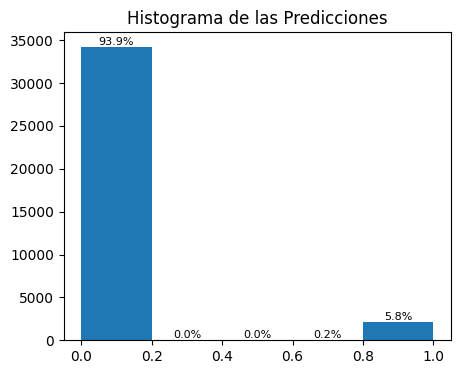

In [11]:
fig, ax = plt.subplots(1, 1, figsize = (5,4))
counts, bins, patches = ax.hist(
    y_train_predict_proba[:,1],
    bins = 5
)
# este total es exclusivo por si quieres hacer % en lugar de conteo al mostrar
total = counts.sum()

for count, patch in zip(counts, patches):
    # para conteo
    #x = patch.get_x() + patch.get_width() / 2 # patch.get_x() → inicio de barra # patch.get_width() → ancho
    #y = patch.get_height() # patch.get_height() → altura (count)
    #ax.text(x, y, int(count), ha = 'center', va = 'bottom', fontsize = 8)
    
    # para porcentaje (%)
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()

    percentage = count / total *100
    ax.text(x, y, f'{percentage:.1f}%', ha = 'center', va = 'bottom', fontsize = 8)

ax.set_title('Histograma de las Predicciones')

plt.savefig('../reports/figures/model_evaluation/03_histogram_predictions.png')

plt.show()


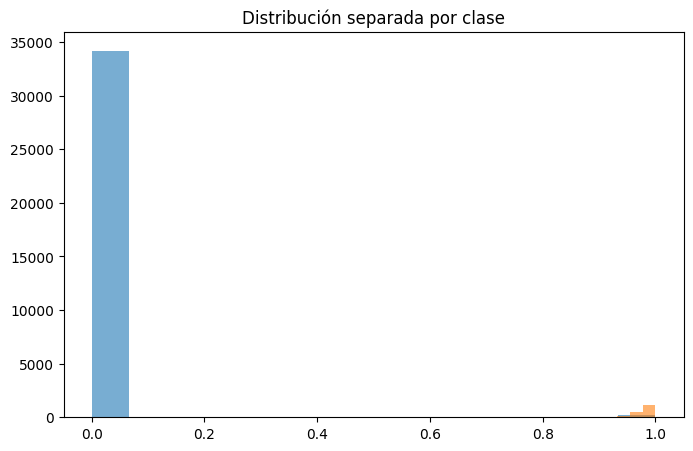

In [15]:
fig, ax = plt.subplots(1, 1, figsize = (8,5))
ax.hist(
    y_train_predict_proba[:, 1][y_train_pre == 0],
    bins= 15,
    alpha = 0.6
)
ax.hist(
    y_train_predict_proba[0:, 1][y_train_pre == 1],
    bins = 15,
    alpha = 0.6
)
ax.set_title('Distribución separada por clase')
plt.savefig('../reports/figures/model_evaluation/03_distribution_class.png')
plt.show()

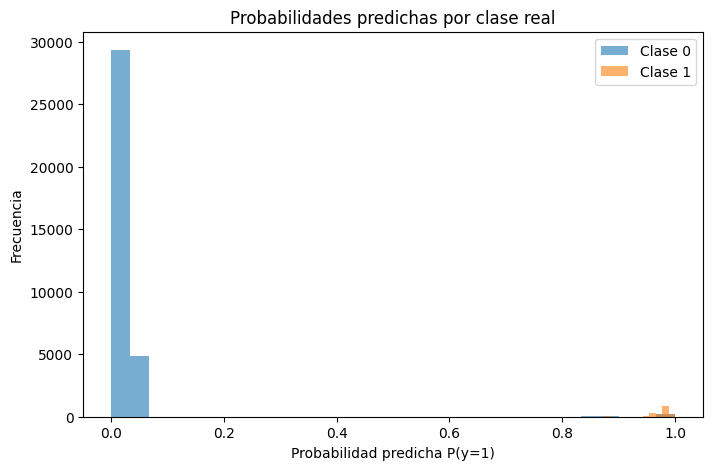

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(y_train_predict_proba[:,1][y_train_pre == 0], bins=30, alpha=0.6, label="Clase 0")
plt.hist(y_train_predict_proba[:,1][y_train_pre == 1], bins=30, alpha=0.6, label="Clase 1")
plt.xlabel("Probabilidad predicha P(y=1)")
plt.ylabel("Frecuencia")
plt.title("Probabilidades predichas por clase real")
plt.legend()
plt.show()

In [17]:
classification_reports = classification_report(y_train_pre, y_train_predictions)
score_accuracy = accuracy_score(y_train_pre, y_train_predictions)
score_f1 = f1_score(y_train_pre, y_train_predictions)
score_recall = recall_score(y_train_pre, y_train_predictions)
score_auc = roc_auc_score(y_train_pre, y_train_predict_proba[:,1])


In [22]:
metrics_train= {
'auc': score_auc,
'accuracy_score': score_accuracy,
'recall': score_recall,
'f1': score_f1
}

with open('../artifacts/model/metrics_train.json', 'w') as f:
    json.dump(metrics_train, f, indent= 4)

In [23]:
## Predicciones del Train
with open('../artifacts/metrics/best_threshold.json', 'r') as f:
    best_threshold = json.load(f)

y_pred_train = np.where(y_train_predict_proba[:,1] >=  best_threshold['threshold'], 1, 0)

metrics_test_oot = pd.DataFrame({
    'y_true': y_train_pre,
    'y_score': y_train_predict_proba[:,1],
    'y_pred': y_pred_train
}).to_parquet('../artifacts/predictions/train_predictions.parquet')

### Registro en MLFlow

In [19]:
import dagshub

In [20]:
dagshub.init(repo_owner='davidrodriguez2712', repo_name='proyecto-3-riesgo-crediticio', mlflow=True)

Accessing as davidrodriguez2712

Initialized MLflow to track repo "davidrodriguez2712/proyecto-3-riesgo-crediticio"

Repository davidrodriguez2712/proyecto-3-riesgo-crediticio initialized!

In [21]:
mlflow.set_tracking_uri('https://dagshub.com/davidrodriguez2712/proyecto-3-riesgo-crediticio.mlflow')

In [22]:
mlflow.set_experiment(experiment_name='Proyecto_3_riesgo_credito')

<Experiment: artifact_location='mlflow-artifacts:/a6c5ecb911f8453daf1b24b248c6b22c', creation_time=1777748161120, experiment_id='2', last_update_time=1777748161120, lifecycle_stage='active', name='Proyecto_3_riesgo_credito', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [ ]:
with mlflow.start_run(run_name= '03_model_training') as run:
    joblib.dump(final_params, '../artifacts/model/logistic_final_params.pkl')
    joblib.dump(best_model_pipeline, '../artifacts/model/logistic_model.pkl')
    joblib.dump(classification_reports, '../reports/metrics/train_classification_report.pkl')
    mlflow.log_artifact('../artifacts/model/logistic_final_params.pkl')
    mlflow.log_artifact('../artifacts/model/logistic_model.pkl')
    mlflow.log_artifact('../reports/figures/model_evaluation/03_distribution_class.png')
    mlflow.log_artifact('../reports/figures/model_evaluation/03_histogram_predictions.png')
    mlflow.log_artifact('../reports/metrics/train_classification_report.pkl')

    mlflow.log_metrics(
        metrics= {
            'auc': score_auc,
            'accuracy_score': score_accuracy,
            'recall': score_recall,
            'f1': score_f1
        }
    )
    
    

🏃 View run 03_model_training at: https://dagshub.com/davidrodriguez2712/proyecto-3-riesgo-crediticio.mlflow/#/experiments/2/runs/49d7fc636fd14a92840c181c8445bf64
🧪 View experiment at: https://dagshub.com/davidrodriguez2712/proyecto-3-riesgo-crediticio.mlflow/#/experiments/2
